# Flight Fare Prediction Using Machine Learning
## AmaliTech NSS - Machine Learning Module Lab

**Objective:** Build an end-to-end ML pipeline for predicting flight fares.

**ML Task:** Supervised Regression
**Target Variable:** Total Fare (BDT)

In [3]:
# !cp -r /kaggle/input/datasets/danielagudeydoe/flight-price-analysis/project/* /kaggle/working

In [4]:
# !rm -rf /kaggle/working/project/

In [5]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## Step 1: Problem Definition & Data Understanding

In [6]:
from src.data_loader import load_dataset, inspect_dataset

df = load_dataset()
summary = inspect_dataset(df)
df.head(10)

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90
5,IndiGo,ZYL,"Osmani International Airport, Sylhet",SPD,Saidpur Airport,2025-06-18 18:28:00,2025-06-18 19:33:06,1.085066,Direct,Airbus A320,Business,Travel Agency,5036.394160,200.000000,5236.394160,Regular,70
6,US-Bangla Airlines,SPD,Saidpur Airport,BZL,Barisal Airport,2025-10-25 22:41:00,2025-10-25 23:45:41,1.078155,Direct,Airbus A320,Business,Direct Booking,7397.669874,200.000000,7597.669874,Regular,28
7,AirAsia,JSR,Jessore Airport,LHR,London Heathrow Airport,2025-12-28 01:38:00,2025-12-28 10:30:49,8.880376,1 Stop,Airbus A350,Economy,Online Website,11946.813583,7792.022037,19738.835620,Winter Holidays,12
8,Etihad Airways,SPD,Saidpur Airport,KUL,Kuala Lumpur International Airport,2025-07-06 21:52:00,2025-07-07 01:09:46,3.296282,Direct,Boeing 787,Business,Travel Agency,74973.621871,17246.043281,92219.665152,Regular,23
9,US-Bangla Airlines,DAC,"Hazrat Shahjalal International Airport, Dhaka",DEL,"Indira Gandhi International Airport, Delhi",2025-04-14 23:19:00,2025-04-15 01:54:44,2.595620,Direct,Boeing 787,First Class,Direct Booking,116951.645445,19542.746817,136494.392261,Regular,41


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                57000 non-null  object 
 1   Source                 57000 non-null  object 
 2   Source Name            57000 non-null  object 
 3   Destination            57000 non-null  object 
 4   Destination Name       57000 non-null  object 
 5   Departure Date & Time  57000 non-null  object 
 6   Arrival Date & Time    57000 non-null  object 
 7   Duration (hrs)         57000 non-null  float64
 8   Stopovers              57000 non-null  object 
 9   Aircraft Type          57000 non-null  object 
 10  Class                  57000 non-null  object 
 11  Booking Source         57000 non-null  object 
 12  Base Fare (BDT)        57000 non-null  float64
 13  Tax & Surcharge (BDT)  57000 non-null  float64
 14  Total Fare (BDT)       57000 non-null  float64
 15  Se

In [8]:
df.describe()

,Duration (hrs),Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Days Before Departure
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,3.994955,58899.556573,11448.238494,71030.316199,45.460579
std,4.094043,68840.614499,12124.344329,81769.199536,26.015657
min,0.500000,1600.975688,200.000000,1800.975688,1.000000
25%,1.003745,8856.316983,200.000000,9602.699787,23.000000
50%,2.644656,31615.996792,9450.940481,41307.544990,45.000000
75%,5.490104,85722.930389,17513.046160,103800.906963,68.000000
max,15.831719,449222.933770,73383.440066,558987.332444,90.000000


In [9]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal duplicate rows: {df.duplicated().sum()}')

Missing values per column:
Airline                  0
Source                   0
Source Name              0
Destination              0
Destination Name         0
Departure Date & Time    0
Arrival Date & Time      0
Duration (hrs)           0
Stopovers                0
Aircraft Type            0
Class                    0
Booking Source           0
Base Fare (BDT)          0
Tax & Surcharge (BDT)    0
Total Fare (BDT)         0
Seasonality              0
Days Before Departure    0
dtype: int64

Total duplicate rows: 0


### Initial Observations
- **Dataset shape:** See `df.shape` after execution
- **Target variable:** Total Fare (BDT)
- **Missing data:** See above
- **Duplicates:** See above

## Step 2: Data Cleaning & Preprocessing

In [10]:
from src.data_cleaning import clean_dataset

df_clean = clean_dataset(df)
print(f'Shape before cleaning: {df.shape}')
print(f'Shape after cleaning:  {df_clean.shape}')
df_clean.head()

Shape before cleaning: (57000, 17)
Shape after cleaning:  (57000, 17)


,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


In [11]:
print('Missing values after cleaning:')
print(df_clean.isnull().sum())
print(f'\nDuplicate rows: {df_clean.duplicated().sum()}')
print(f'\nData types:\n{df_clean.dtypes}')

Missing values after cleaning:
Airline                  0
Source                   0
Source Name              0
Destination              0
Destination Name         0
Departure Date & Time    0
Arrival Date & Time      0
Duration (hrs)           0
Stopovers                0
Aircraft Type            0
Class                    0
Booking Source           0
Base Fare (BDT)          0
Tax & Surcharge (BDT)    0
Total Fare (BDT)         0
Seasonality              0
Days Before Departure    0
dtype: int64

Duplicate rows: 0

Data types:
Airline                          object
Source                           object
Source Name                      object
Destination                      object
Destination Name                 object
Departure Date & Time    datetime64[ns]
Arrival Date & Time      datetime64[ns]
Duration (hrs)                  float64
Stopovers                        object
Aircraft Type                    object
Class                            object
Booking Source           

## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Descriptive Statistics

In [12]:
from src.eda import summarize_fares, compute_kpis

fare_summary = summarize_fares(df_clean)
fare_summary

,Mean,Median,Std,Min,Max,Count
Airline,,,,,,
Turkish Airlines,75547.27,43172.68,86133.38,1842.79,558987.33,2220
AirAsia,74534.39,42763.82,85962.63,1804.13,415248.03,2312
Cathay Pacific,73325.09,46282.46,83285.51,1805.89,419822.09,2282
Thai Airways,72845.79,42898.83,83424.34,1814.62,447814.56,2316
Malaysian Airlines,72775.18,41938.11,82382.28,1872.76,482855.60,2292
IndiGo,72504.43,42018.49,83581.70,1809.27,524278.76,2223
Air India,72474.18,42429.62,83772.26,1816.37,404646.53,2280
US-Bangla Airlines,72088.29,41255.33,82114.58,1801.20,437270.96,4496
Kuwait Airways,71988.28,39584.26,83430.85,1806.92,458420.04,2262


In [13]:
kpis = compute_kpis(df_clean)
for key, value in kpis.items():
    print(f'{key}: {value}')

avg_fare_per_airline: {'Air Arabia': 69924.0069653591, 'Air Astra': 68497.40780385124, 'Air India': 72474.17841927757, 'AirAsia': 74534.39065085599, 'Biman Bangladesh Airlines': 70192.96928740495, 'British Airways': 70555.53620528667, 'Cathay Pacific': 73325.09112407768, 'Emirates': 70106.14941295658, 'Etihad Airways': 71785.24204541481, 'FlyDubai': 68987.68920579819, 'Gulf Air': 71458.16382764814, 'IndiGo': 72504.43312224906, 'Kuwait Airways': 71988.27610740755, 'Lufthansa': 69293.16387889728, 'Malaysian Airlines': 72775.18020054615, 'NovoAir': 68350.8592477514, 'Qatar Airways': 69865.53648745059, 'Saudia': 69270.67612310106, 'Singapore Airlines': 68323.93091354895, 'SriLankan Airlines': 71265.261153516, 'Thai Airways': 72845.78999276276, 'Turkish Airlines': 75547.2686286511, 'US-Bangla Airlines': 72088.28902479199, 'Vistara': 68108.2388436122}
most_expensive_airline: Turkish Airlines
cheapest_airline: Vistara
most_popular_route: RJH -> SIN
popular_route_count: 417
top_5_expensive_rou

### 3.2 Visual Analysis

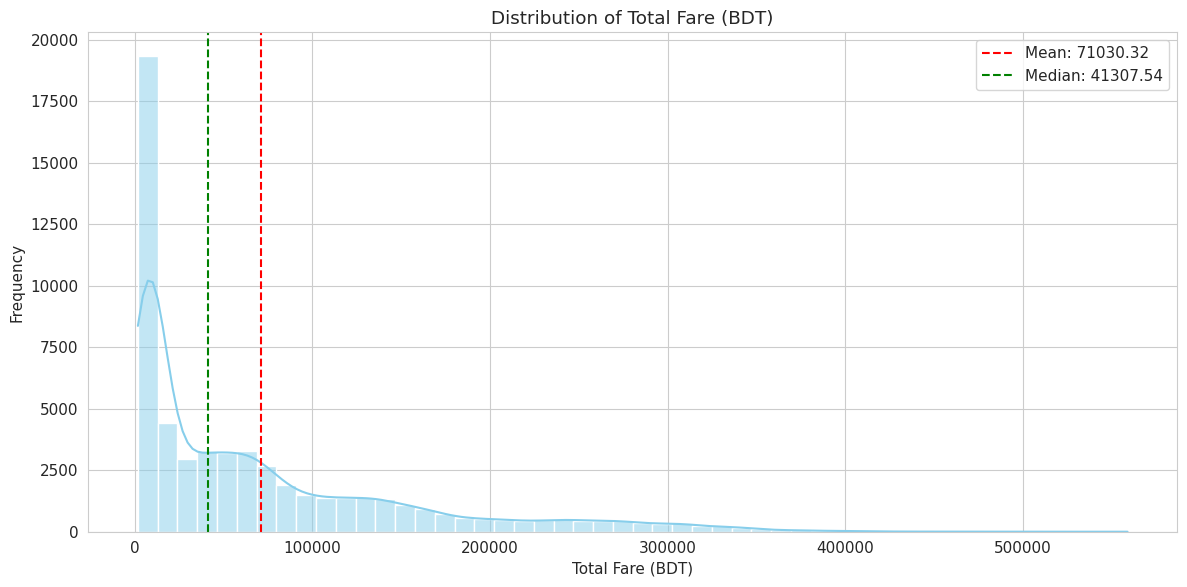

In [14]:
from src.eda import plot_fare_distribution
plot_fare_distribution(df_clean)

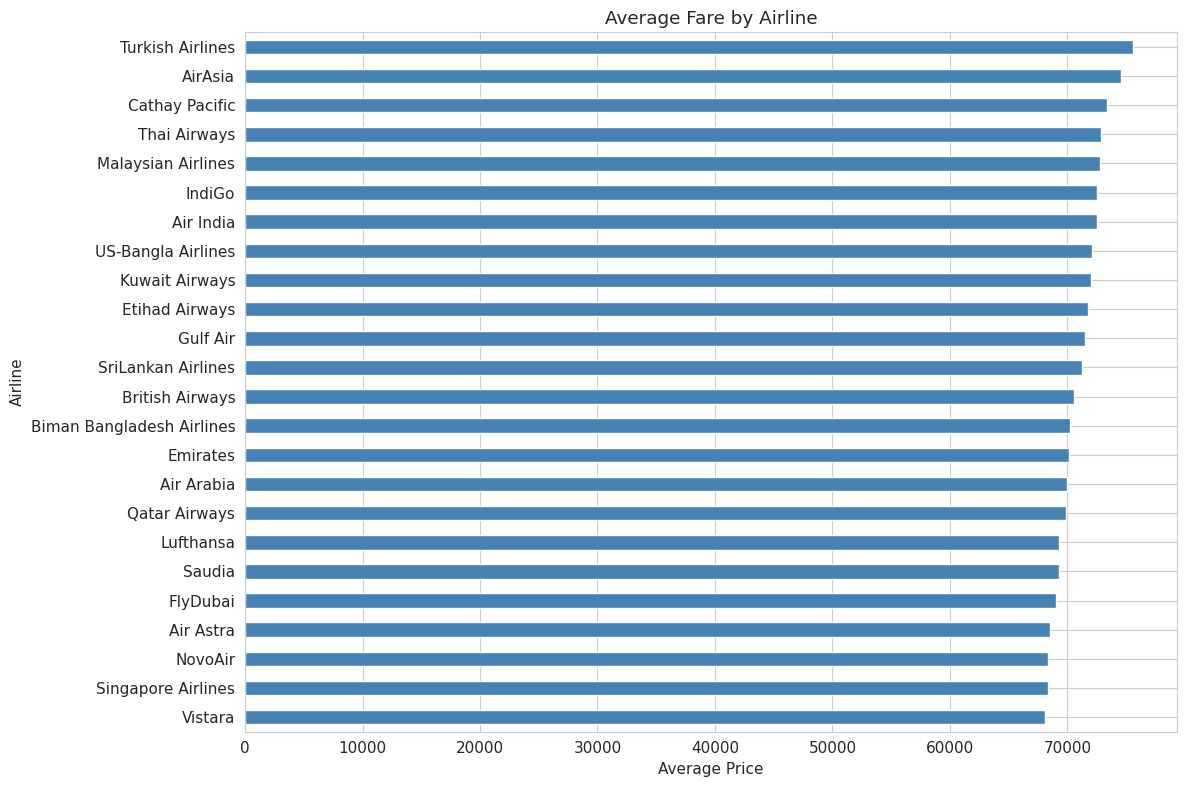

In [15]:
from src.eda import plot_fare_by_airline
plot_fare_by_airline(df_clean)

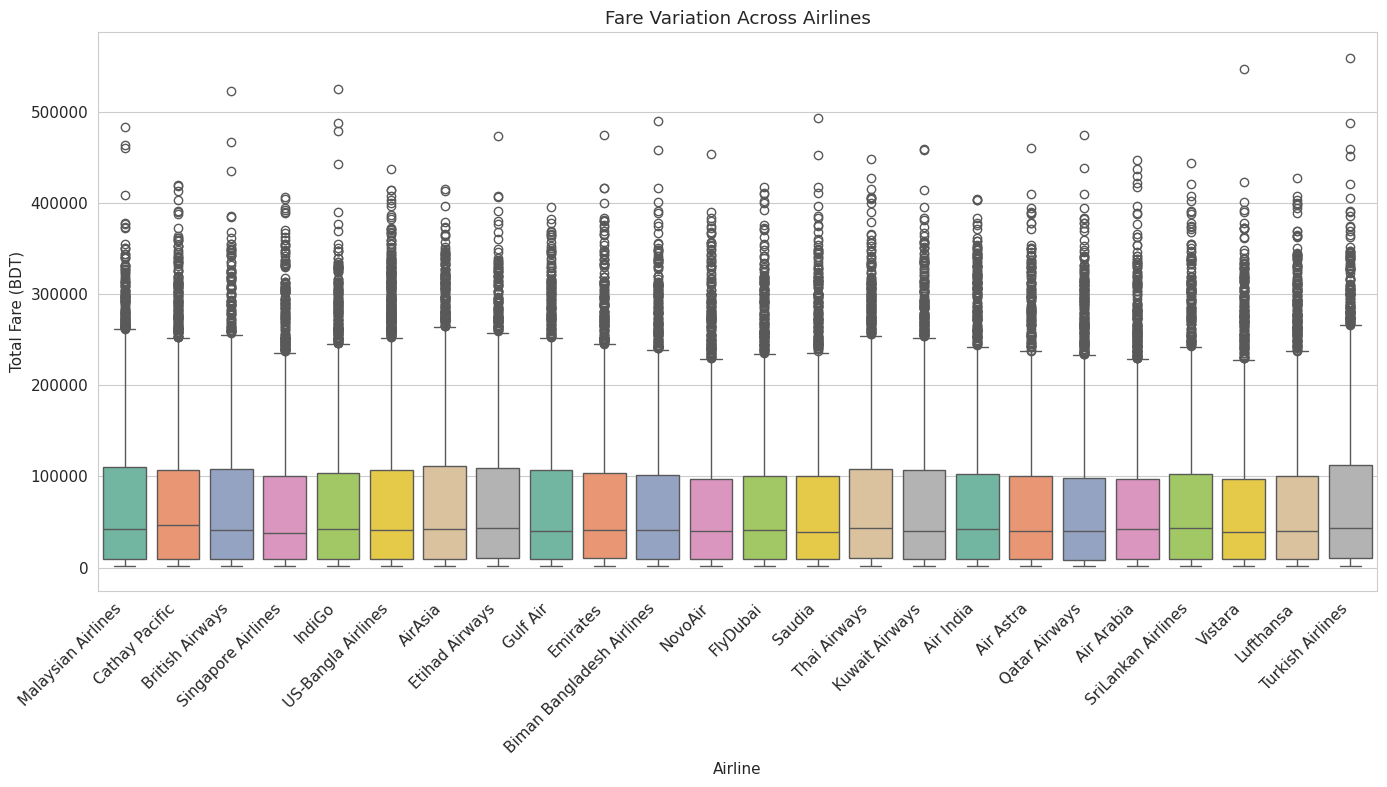

In [16]:
from src.eda import plot_fare_boxplots
plot_fare_boxplots(df_clean)

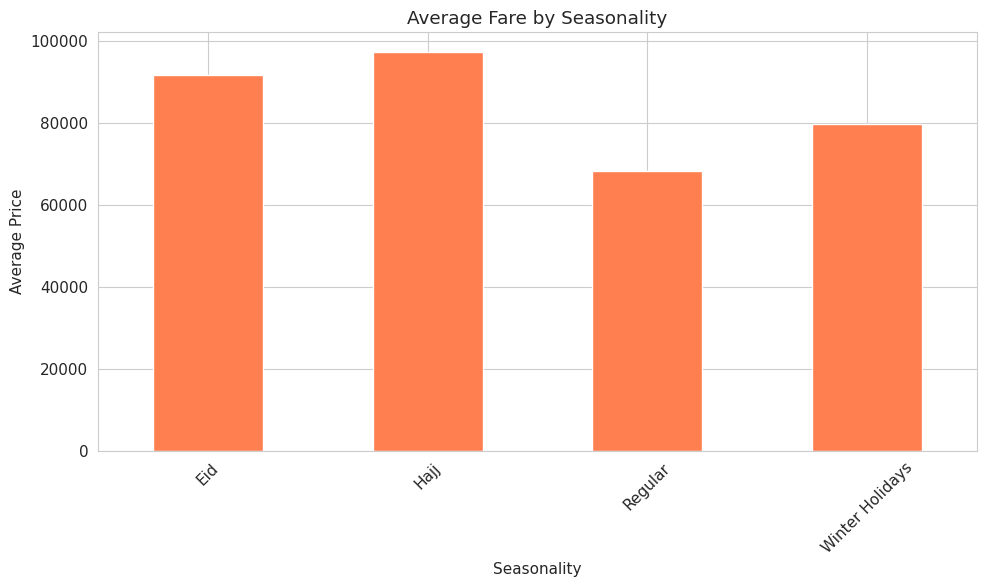

In [17]:
from src.eda import plot_fare_by_season
plot_fare_by_season(df_clean)

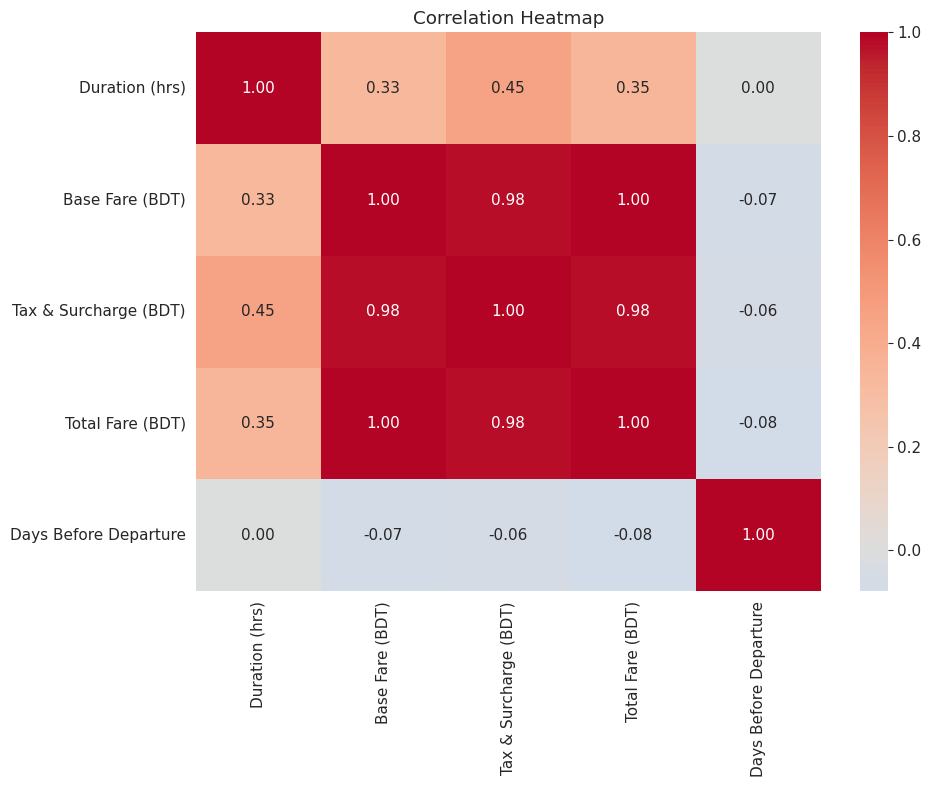

In [18]:
from src.eda import plot_correlation_heatmap
plot_correlation_heatmap(df_clean)

### 3.3 Key EDA Findings

## Step 4: Feature Engineering

In [19]:
from src.feature_engineering import run_feature_pipeline

X_train, X_test, y_train, y_test, scaler, feature_names = run_feature_pipeline(df_clean)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Features:     {len(feature_names)}')
print(f'\nFeature names: {feature_names}')

Training set: (45600, 248)
Test set:     (11400, 248)
Features:     248

Feature names: ['Duration (hrs)', 'Days Before Departure', 'Month', 'Day', 'Weekday', 'Hour', 'Airline_Air Astra', 'Airline_Air India', 'Airline_AirAsia', 'Airline_Biman Bangladesh Airlines', 'Airline_British Airways', 'Airline_Cathay Pacific', 'Airline_Emirates', 'Airline_Etihad Airways', 'Airline_FlyDubai', 'Airline_Gulf Air', 'Airline_IndiGo', 'Airline_Kuwait Airways', 'Airline_Lufthansa', 'Airline_Malaysian Airlines', 'Airline_NovoAir', 'Airline_Qatar Airways', 'Airline_Saudia', 'Airline_Singapore Airlines', 'Airline_SriLankan Airlines', 'Airline_Thai Airways', 'Airline_Turkish Airlines', 'Airline_US-Bangla Airlines', 'Airline_Vistara', 'Source_CGP', 'Source_CXB', 'Source_DAC', 'Source_JSR', 'Source_RJH', 'Source_SPD', 'Source_ZYL', "Source Name_Cox's Bazar Airport", 'Source Name_Hazrat Shahjalal International Airport, Dhaka', 'Source Name_Jessore Airport', 'Source Name_Osmani International Airport, Sylhet', '

In [20]:
print('Target variable (y_train) statistics:')
print(y_train.describe())
print(f'\nNaN values in X_train: {X_train.isnull().sum().sum()}')
print(f'NaN values in X_test: {X_test.isnull().sum().sum()}')

Target variable (y_train) statistics:
count     45600.000000
mean      71099.889276
std       81799.414932
min        1801.196913
25%        9602.699787
50%       41228.181689
75%      103862.338193
max      558987.332444
Name: Total Fare (BDT), dtype: float64

NaN values in X_train: 0
NaN values in X_test: 0


## Step 5: Baseline Models

### 5.1 Linear Regression

In [21]:
from src.models import (
    train_and_evaluate_linear_regression,
    plot_actual_vs_predicted,
    plot_residuals,
    plot_linear_coefficients
)

lr_model, lr_pred, lr_results = train_and_evaluate_linear_regression(
    X_train, X_test, y_train, y_test, feature_names
)

print('\n' + '='*60)
print('LINEAR REGRESSION RESULTS')
print('='*60)
print(f'Train R2:  {lr_results["Train_R2"]:.6f}')
print(f'Test R2:   {lr_results["Test_R2"]:.6f}')
print(f'Test RMSE: {lr_results["Test_RMSE"]:.2f} BDT')
print(f'Test MAE:  {lr_results["Test_MAE"]:.2f} BDT')
print(f'CV R2:     {lr_results["CV_R2_Mean"]:.6f} (+/- {lr_results["CV_R2_Std"]:.6f})')


LINEAR REGRESSION RESULTS
Train R2:  0.575141
Test R2:   0.568567
Test RMSE: 53629.09 BDT
Test MAE:  40774.93 BDT
CV R2:     0.570964 (+/- 0.004744)


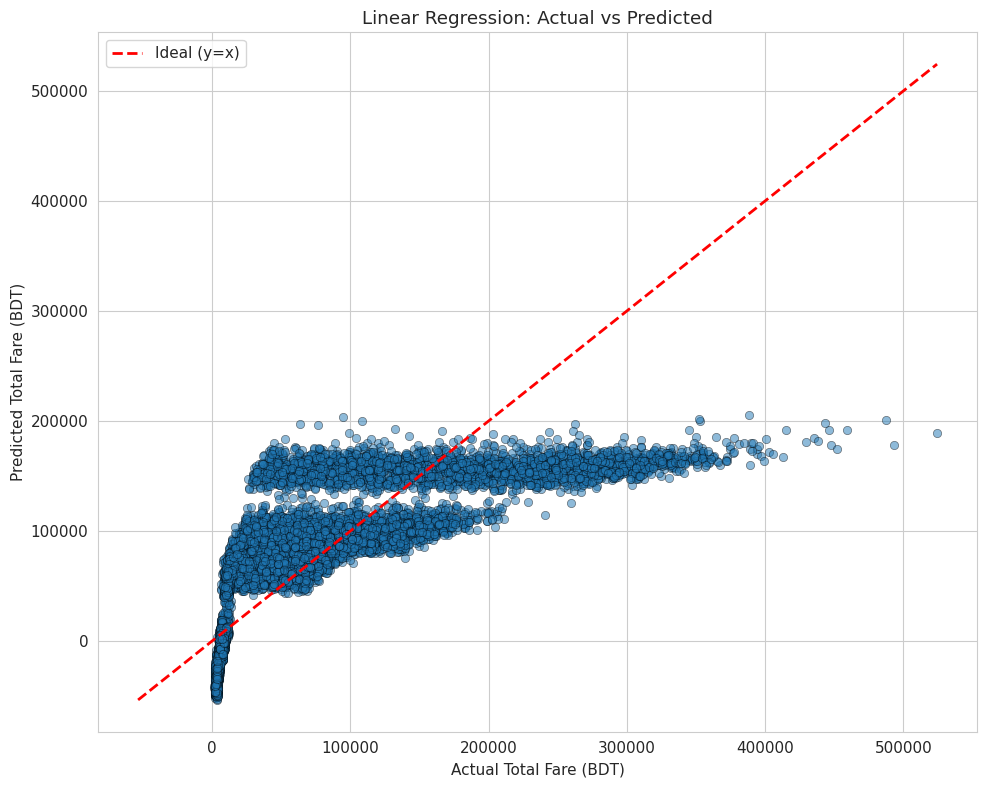

In [22]:
plot_actual_vs_predicted(y_test.values, lr_pred, 'Linear Regression')

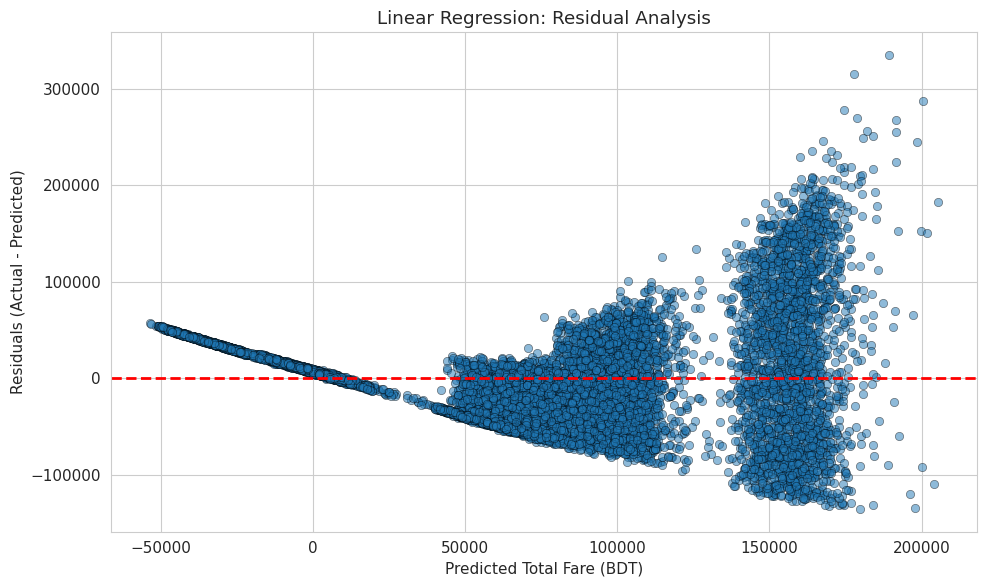

In [23]:
plot_residuals(y_test.values, lr_pred, 'Linear Regression')

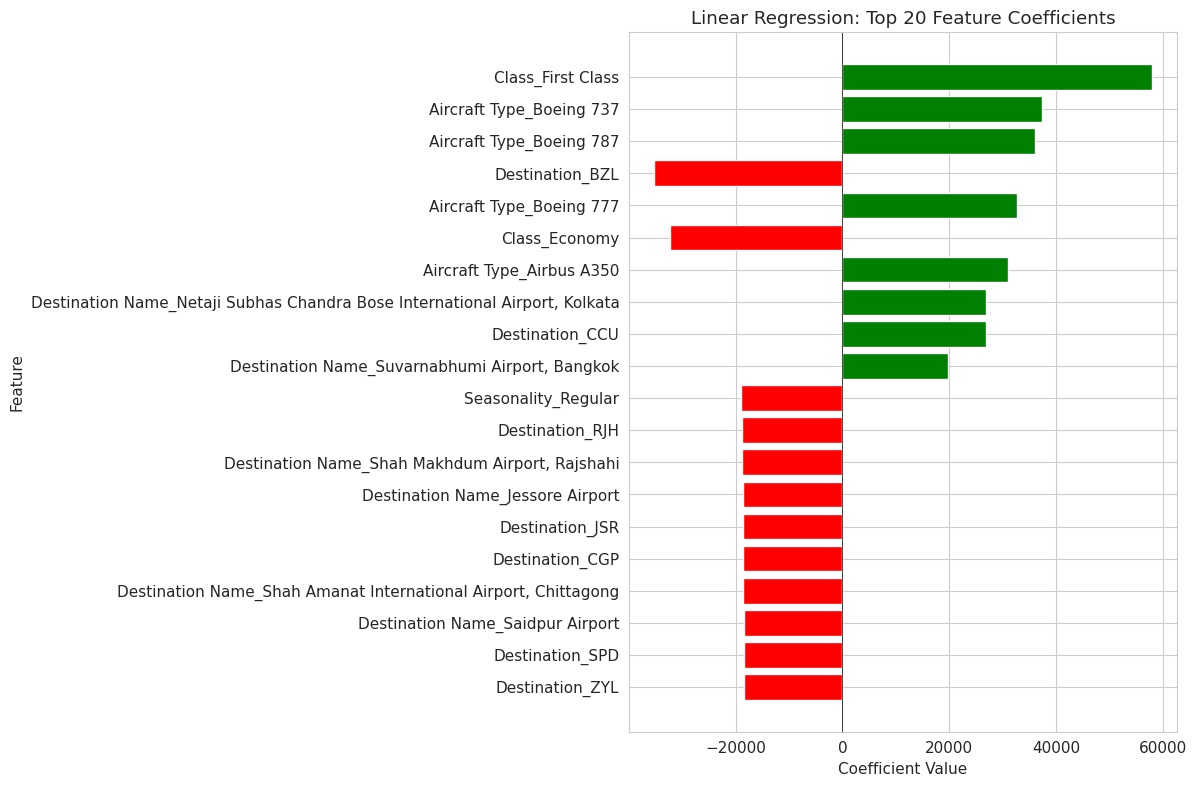

In [24]:
plot_linear_coefficients(lr_model, feature_names, 'Linear Regression')

### 5.2 Ridge Regression

In [25]:
from src.models import train_and_evaluate_ridge

ridge_model, ridge_pred, ridge_results = train_and_evaluate_ridge(
    X_train, X_test, y_train, y_test, feature_names
)

print('\n' + '='*60)
print('RIDGE REGRESSION RESULTS')
print('='*60)
print(f'Train R2:  {ridge_results["Train_R2"]:.6f}')
print(f'Test R2:   {ridge_results["Test_R2"]:.6f}')
print(f'Test RMSE: {ridge_results["Test_RMSE"]:.2f} BDT')
print(f'Test MAE:  {ridge_results["Test_MAE"]:.2f} BDT')
print(f'CV R2:     {ridge_results["CV_R2_Mean"]:.6f} (+/- {ridge_results["CV_R2_Std"]:.6f})')


RIDGE REGRESSION RESULTS
Train R2:  0.575141
Test R2:   0.568571
Test RMSE: 53628.84 BDT
Test MAE:  40772.02 BDT
CV R2:     0.570979 (+/- 0.004735)


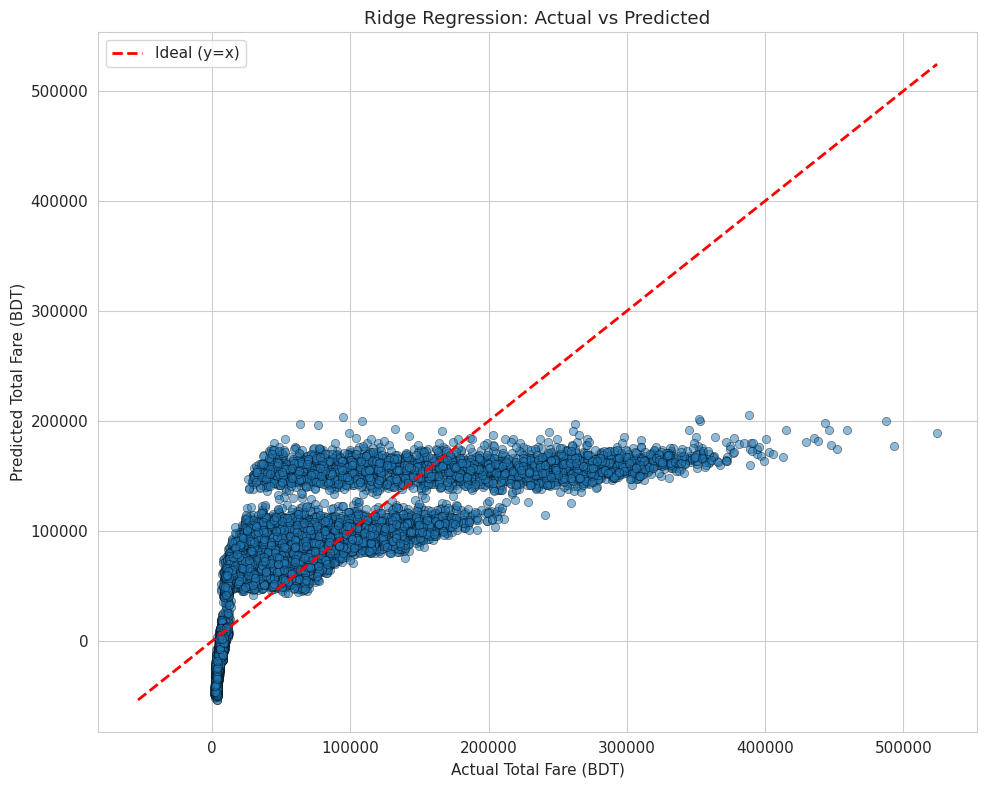

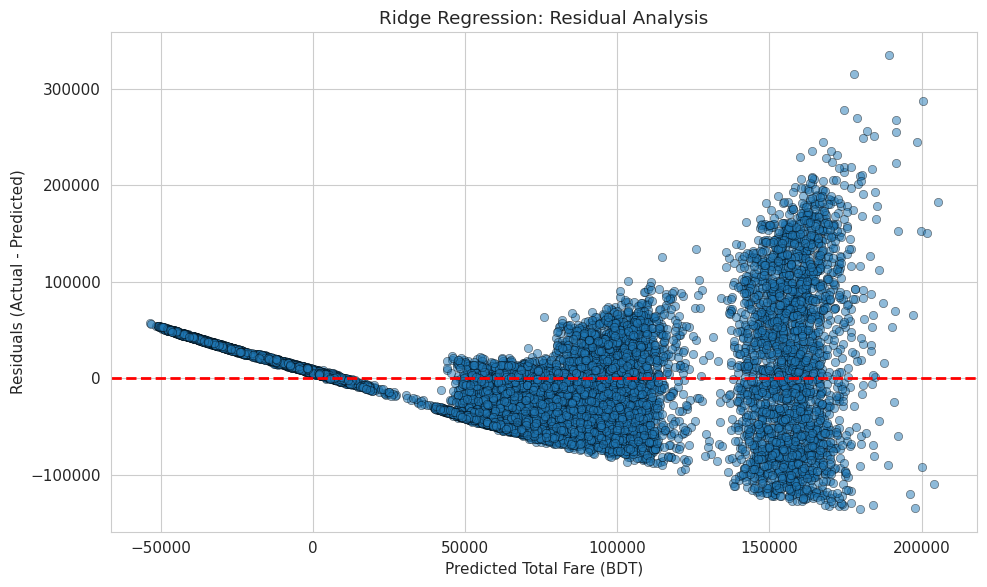

In [26]:
plot_actual_vs_predicted(y_test.values, ridge_pred, 'Ridge Regression')
plot_residuals(y_test.values, ridge_pred, 'Ridge Regression')

### 5.3 Lasso Regression

In [27]:
from src.models import train_and_evaluate_lasso

lasso_model, lasso_pred, lasso_results = train_and_evaluate_lasso(
    X_train, X_test, y_train, y_test, feature_names
)

print('\n' + '='*60)
print('LASSO REGRESSION RESULTS')
print('='*60)
print(f'Train R2:  {lasso_results["Train_R2"]:.6f}')
print(f'Test R2:   {lasso_results["Test_R2"]:.6f}')
print(f'Test RMSE: {lasso_results["Test_RMSE"]:.2f} BDT')
print(f'Test MAE:  {lasso_results["Test_MAE"]:.2f} BDT')
print(f'CV R2:     {lasso_results["CV_R2_Mean"]:.6f} (+/- {lasso_results["CV_R2_Std"]:.6f})')


LASSO REGRESSION RESULTS
Train R2:  0.575136
Test R2:   0.568639
Test RMSE: 53624.59 BDT
Test MAE:  40764.65 BDT
CV R2:     0.571092 (+/- 0.004735)


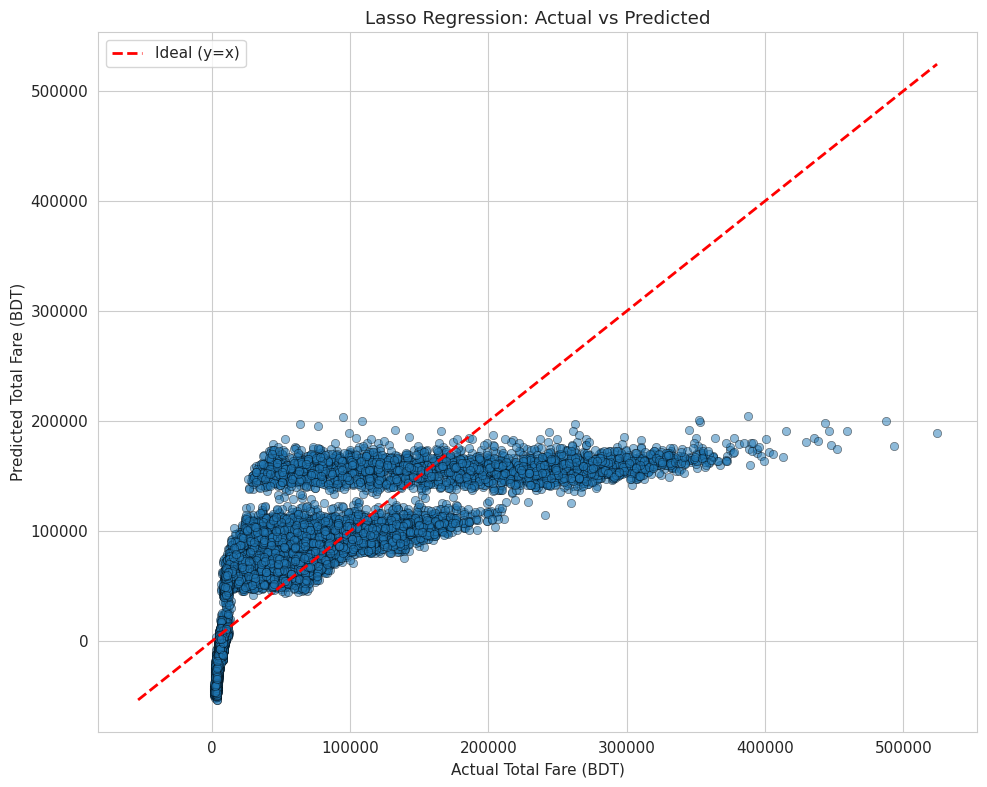

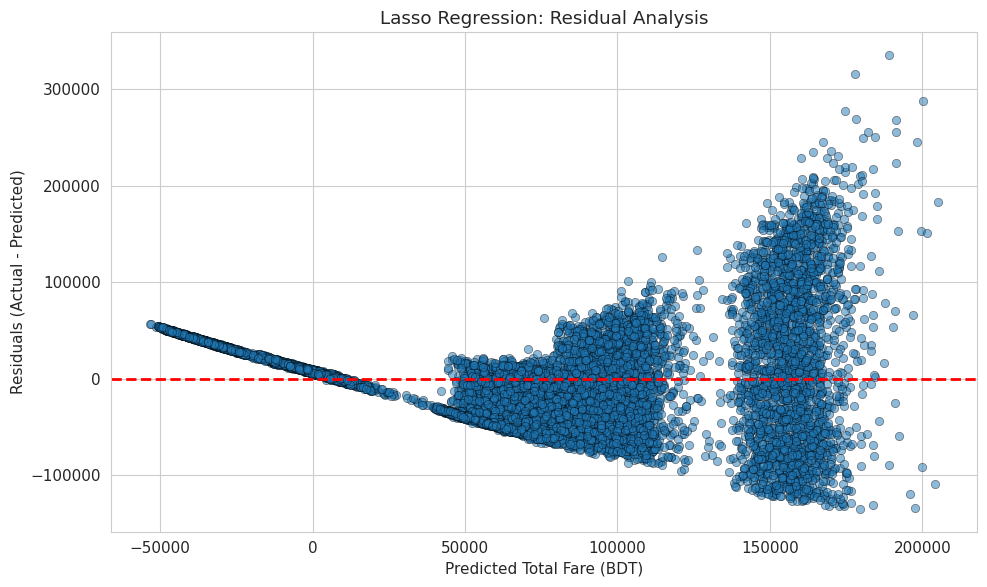

In [28]:
plot_actual_vs_predicted(y_test.values, lasso_pred, 'Lasso Regression')
plot_residuals(y_test.values, lasso_pred, 'Lasso Regression')

## Step 6: Advanced Models

### 6.1 Decision Tree Regressor

In [29]:
from src.models import (
    train_and_evaluate_decision_tree,
    plot_feature_importance
)

dt_model, dt_pred, dt_results = train_and_evaluate_decision_tree(
    X_train, X_test, y_train, y_test, feature_names
)

print('\n' + '='*60)
print('DECISION TREE RESULTS')
print('='*60)
print(f'Train R2:  {dt_results["Train_R2"]:.6f}')
print(f'Test R2:   {dt_results["Test_R2"]:.6f}')
print(f'Test RMSE: {dt_results["Test_RMSE"]:.2f} BDT')
print(f'Test MAE:  {dt_results["Test_MAE"]:.2f} BDT')
print(f'CV R2:     {dt_results["CV_R2_Mean"]:.6f} (+/- {dt_results["CV_R2_Std"]:.6f})')


DECISION TREE RESULTS
Train R2:  0.717725
Test R2:   0.645536
Test RMSE: 48610.43 BDT
Test MAE:  28725.79 BDT
CV R2:     0.645384 (+/- 0.007411)


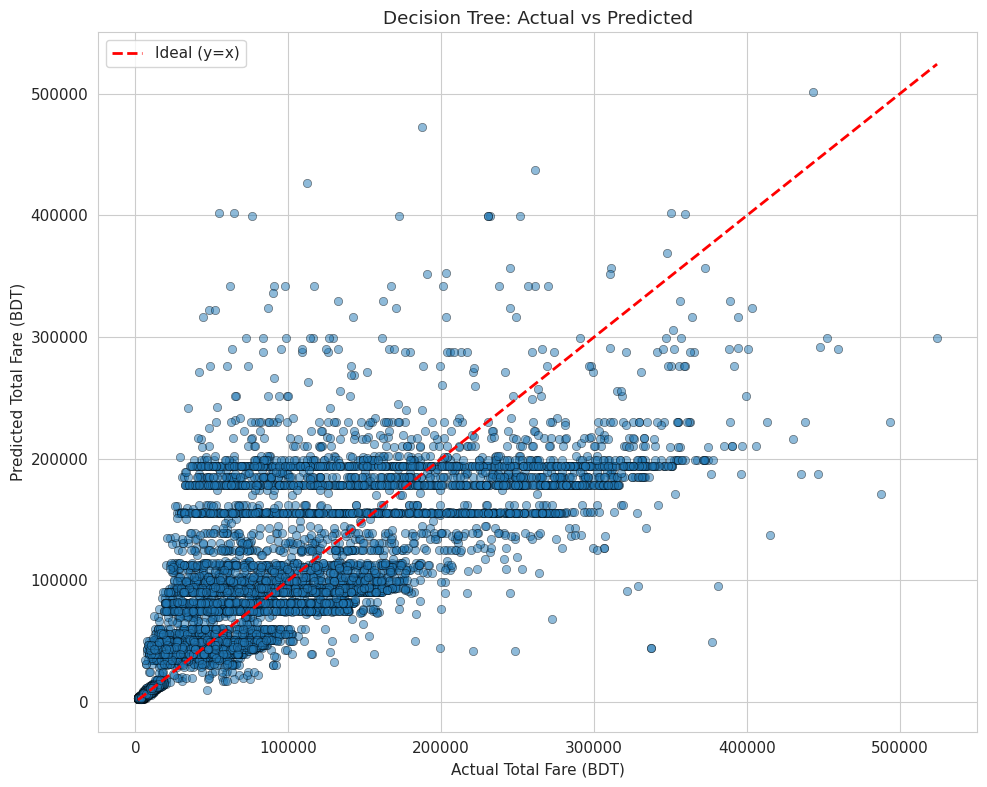

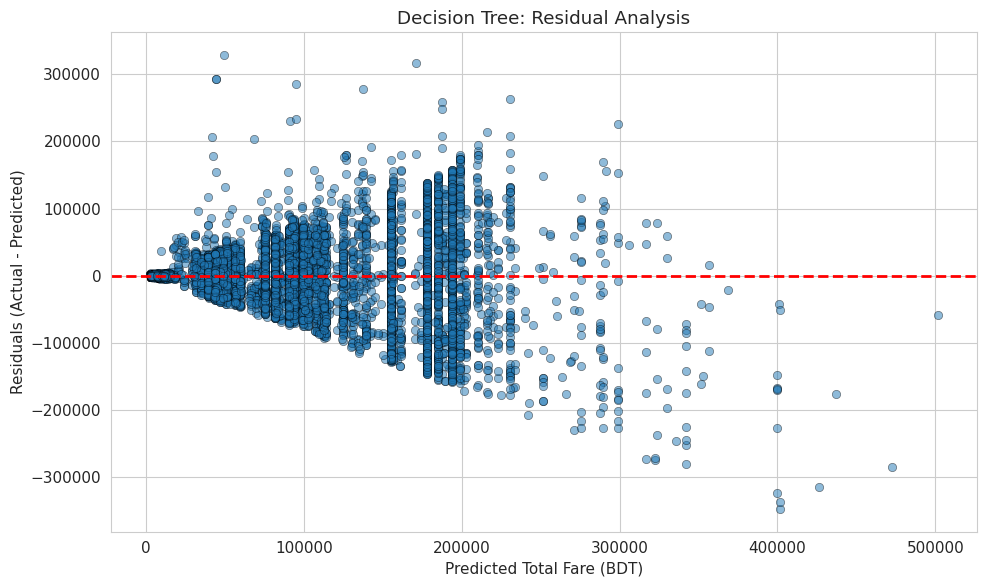

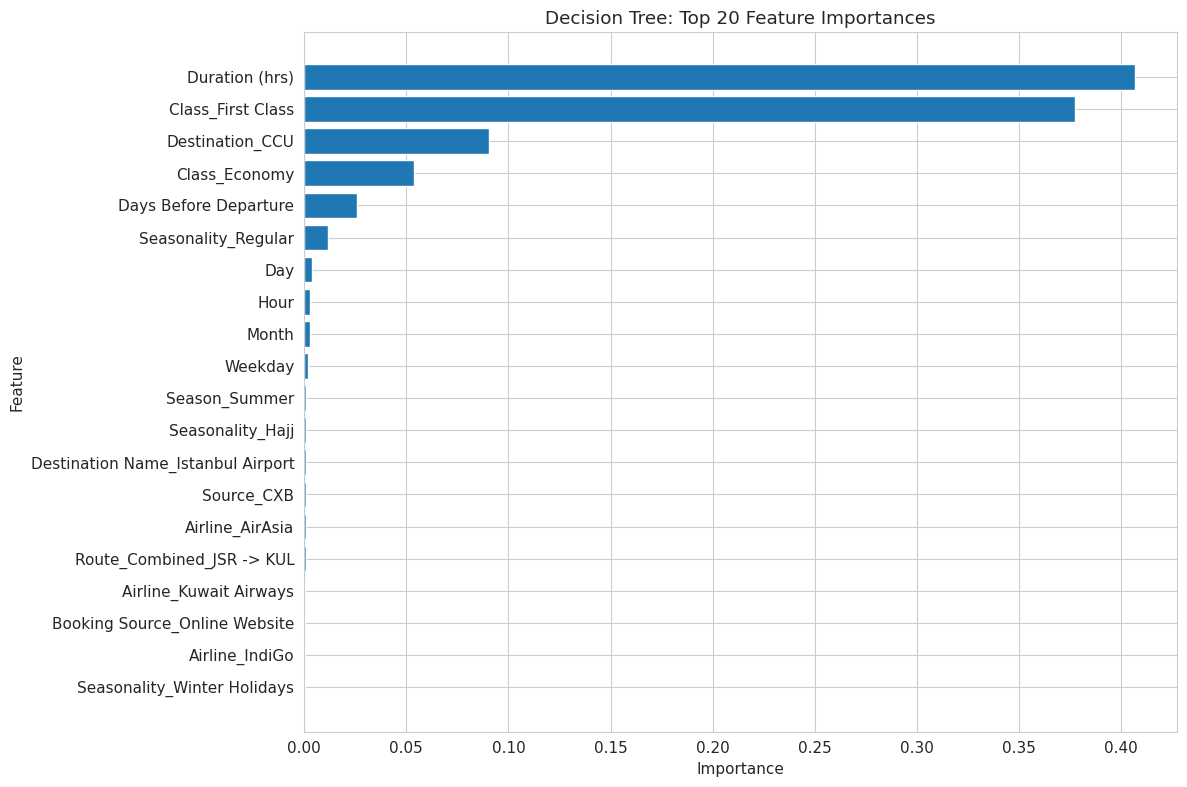

In [30]:
plot_actual_vs_predicted(y_test.values, dt_pred, 'Decision Tree')
plot_residuals(y_test.values, dt_pred, 'Decision Tree')
plot_feature_importance(dt_model, feature_names, 'Decision Tree')

### 6.2 Random Forest Regressor

In [31]:
from src.models import train_and_evaluate_random_forest

rf_model, rf_pred, rf_results = train_and_evaluate_random_forest(
    X_train, X_test, y_train, y_test, feature_names
)

print('\n' + '='*60)
print('RANDOM FOREST RESULTS')
print('='*60)
print(f'Train R2:  {rf_results["Train_R2"]:.6f}')
print(f'Test R2:   {rf_results["Test_R2"]:.6f}')
print(f'Test RMSE: {rf_results["Test_RMSE"]:.2f} BDT')
print(f'Test MAE:  {rf_results["Test_MAE"]:.2f} BDT')
print(f'CV R2:     {rf_results["CV_R2_Mean"]:.6f} (+/- {rf_results["CV_R2_Std"]:.6f})')


RANDOM FOREST RESULTS
Train R2:  0.732644
Test R2:   0.677634
Test RMSE: 46357.31 BDT
Test MAE:  27848.40 BDT
CV R2:     0.679921 (+/- 0.005968)


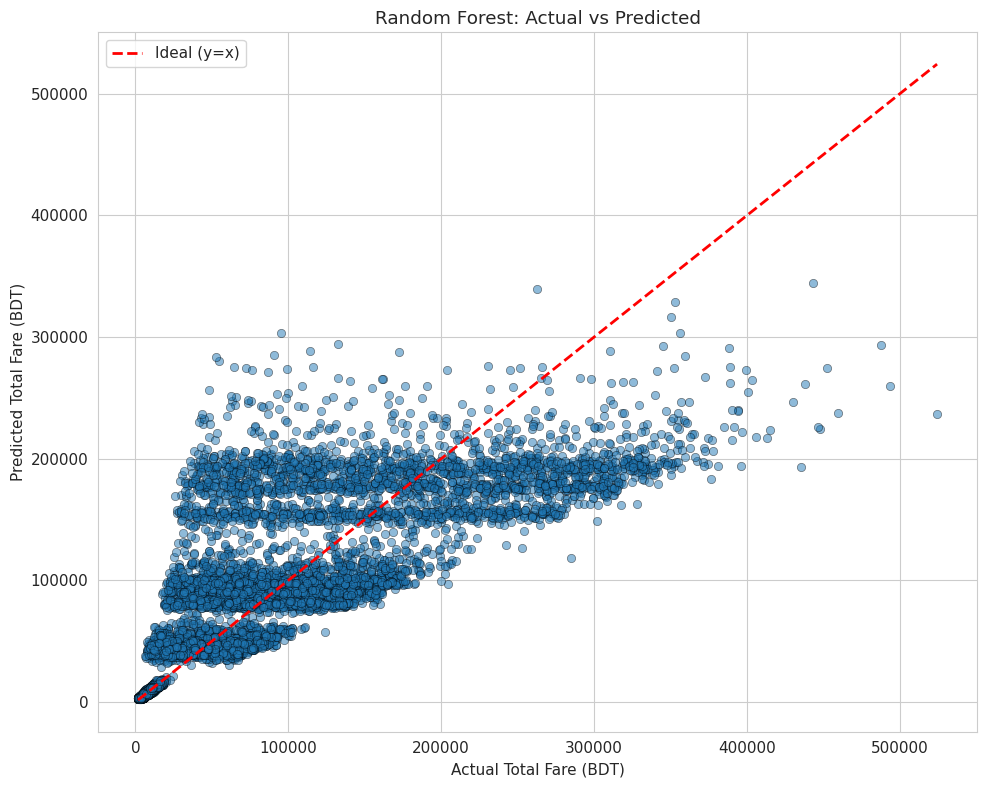

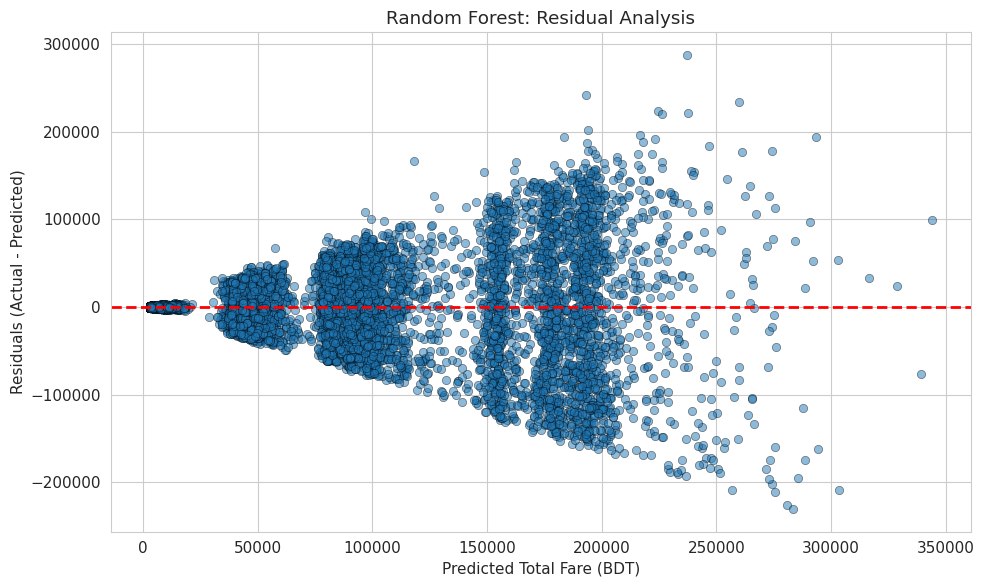

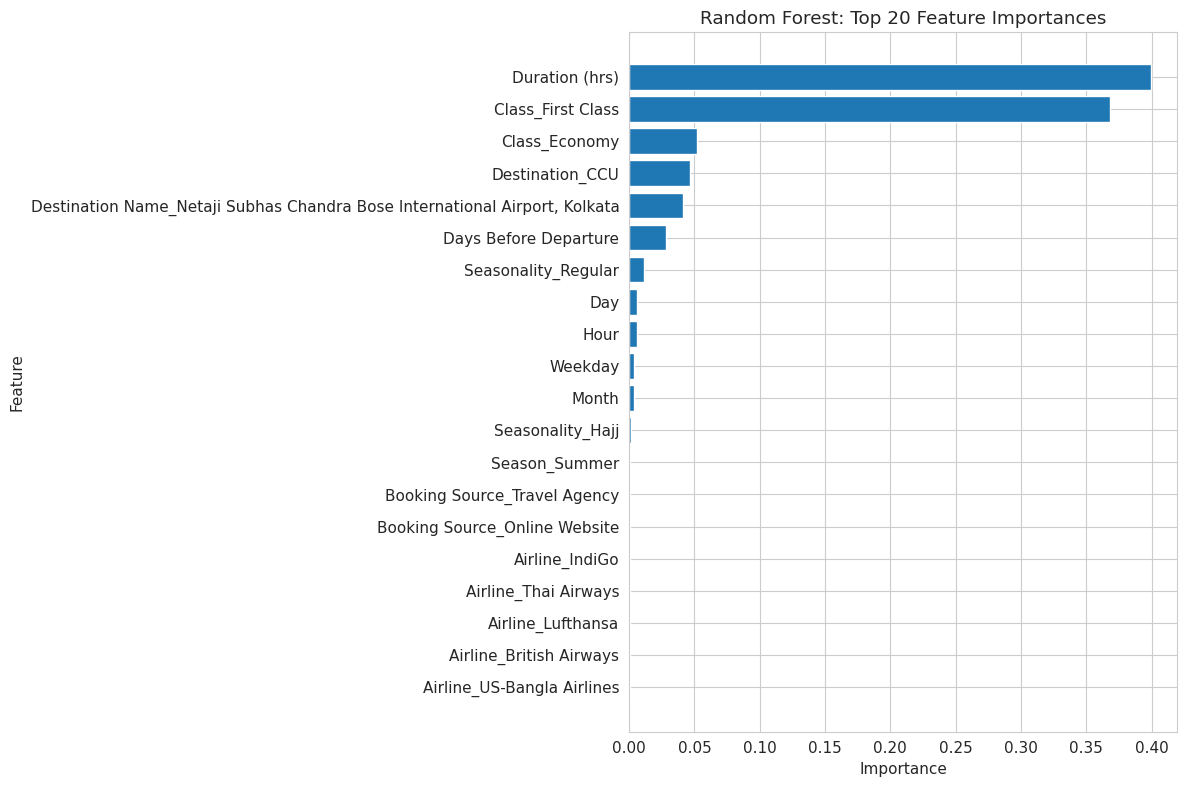

In [32]:
plot_actual_vs_predicted(y_test.values, rf_pred, 'Random Forest')
plot_residuals(y_test.values, rf_pred, 'Random Forest')
plot_feature_importance(rf_model, feature_names, 'Random Forest')

### 6.3 Gradient Boosting Regressor

In [33]:
from src.models import train_and_evaluate_gradient_boosting

gb_model, gb_pred, gb_results = train_and_evaluate_gradient_boosting(
    X_train, X_test, y_train, y_test, feature_names
)

print('\n' + '='*60)
print('GRADIENT BOOSTING RESULTS')
print('='*60)
print(f'Train R2:  {gb_results["Train_R2"]:.6f}')
print(f'Test R2:   {gb_results["Test_R2"]:.6f}')
print(f'Test RMSE: {gb_results["Test_RMSE"]:.2f} BDT')
print(f'Test MAE:  {gb_results["Test_MAE"]:.2f} BDT')
print(f'CV R2:     {gb_results["CV_R2_Mean"]:.6f} (+/- {gb_results["CV_R2_Std"]:.6f})')


GRADIENT BOOSTING RESULTS
Train R2:  0.712128
Test R2:   0.677027
Test RMSE: 46400.96 BDT
Test MAE:  27926.92 BDT
CV R2:     0.680531 (+/- 0.005465)


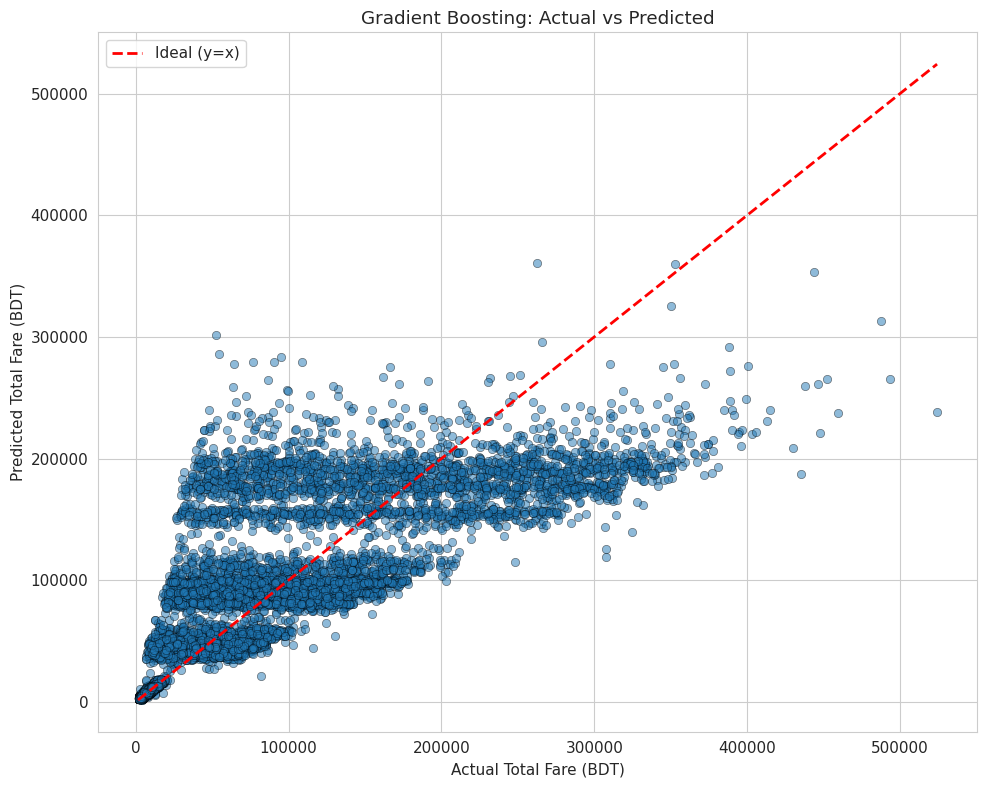

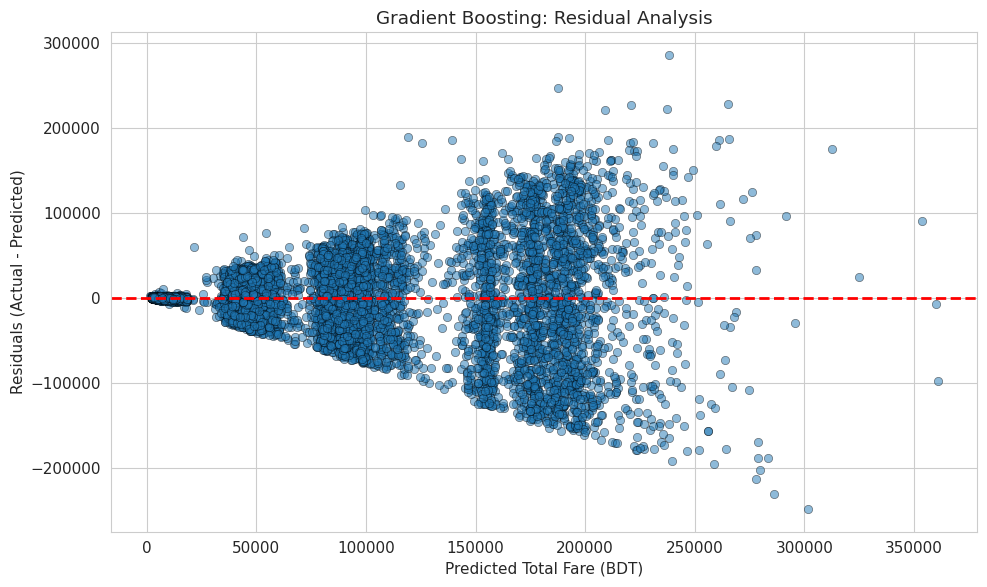

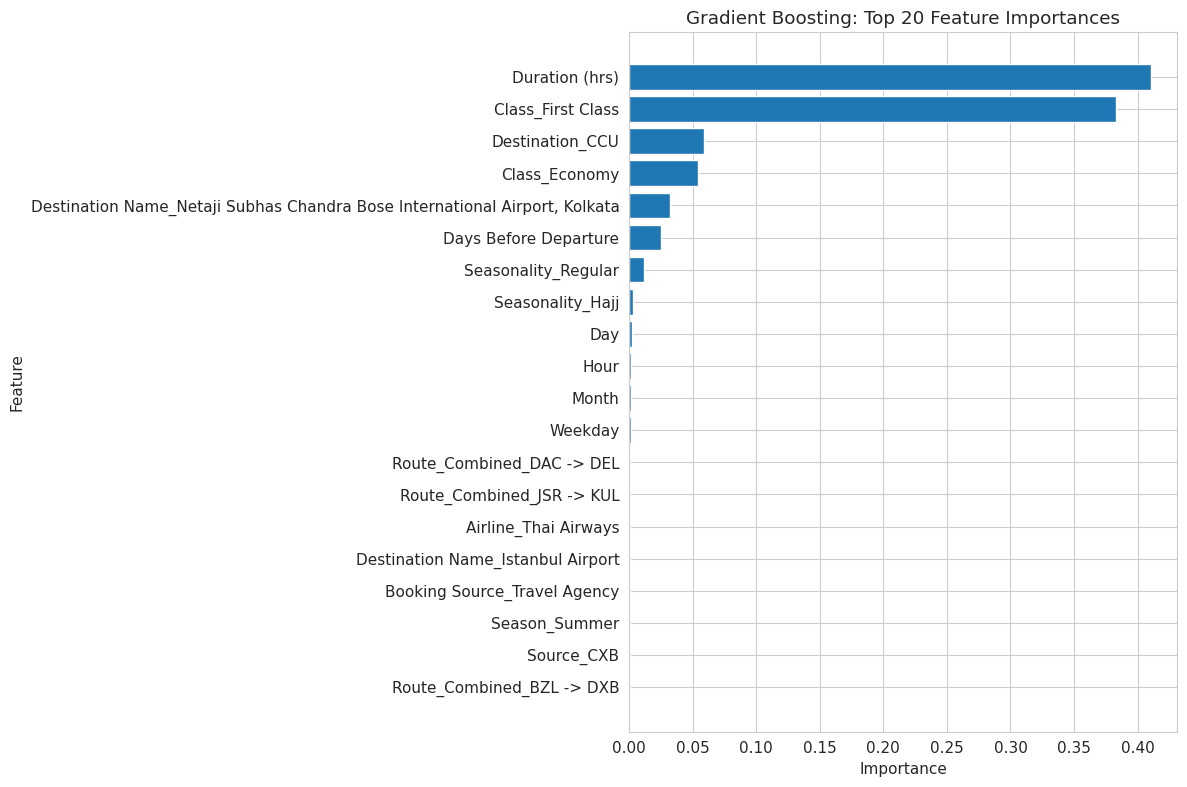

In [34]:
plot_actual_vs_predicted(y_test.values, gb_pred, 'Gradient Boosting')
plot_residuals(y_test.values, gb_pred, 'Gradient Boosting')
plot_feature_importance(gb_model, feature_names, 'Gradient Boosting')

### 6.4 XGBoost Regressor

In [35]:
from src.models import train_and_evaluate_xgboost

xgb_model, xgb_pred, xgb_results = train_and_evaluate_xgboost(
    X_train, X_test, y_train, y_test, feature_names
)

print('\n' + '='*60)
print('XGBOOST RESULTS')
print('='*60)
print(f'Train R2:  {xgb_results["Train_R2"]:.6f}')
print(f'Test R2:   {xgb_results["Test_R2"]:.6f}')
print(f'Test RMSE: {xgb_results["Test_RMSE"]:.2f} BDT')
print(f'Test MAE:  {xgb_results["Test_MAE"]:.2f} BDT')
print(f'CV R2:     {xgb_results["CV_R2_Mean"]:.6f} (+/- {xgb_results["CV_R2_Std"]:.6f})')


XGBOOST RESULTS
Train R2:  0.711971
Test R2:   0.677104
Test RMSE: 46395.44 BDT
Test MAE:  27945.26 BDT
CV R2:     0.680735 (+/- 0.005601)


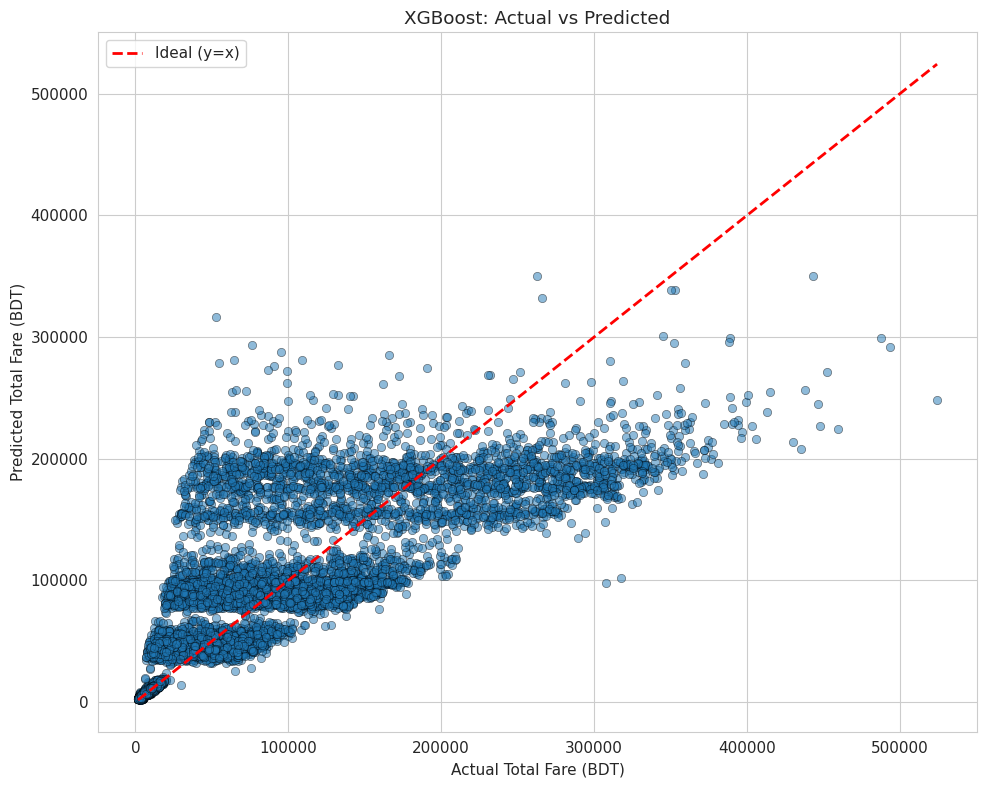

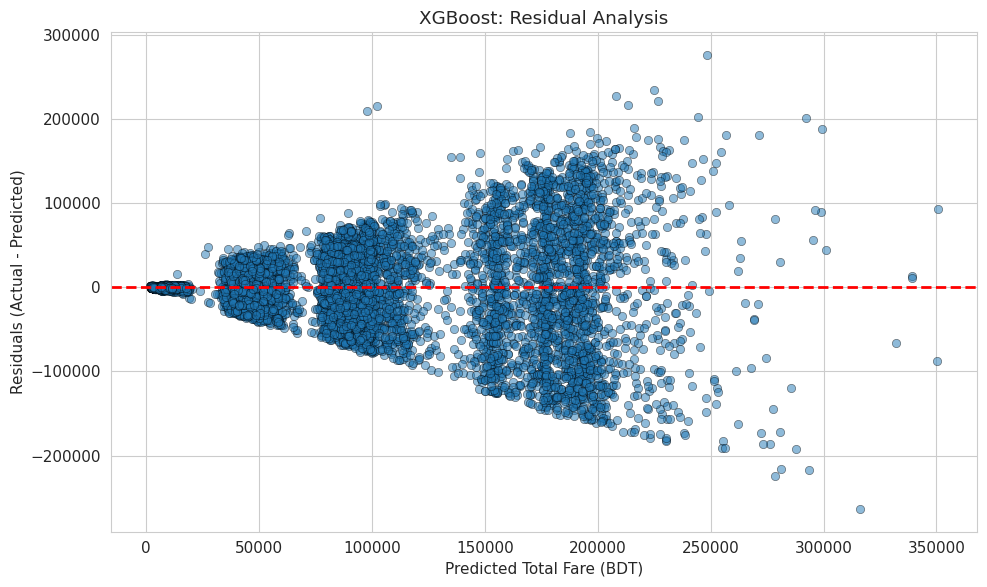

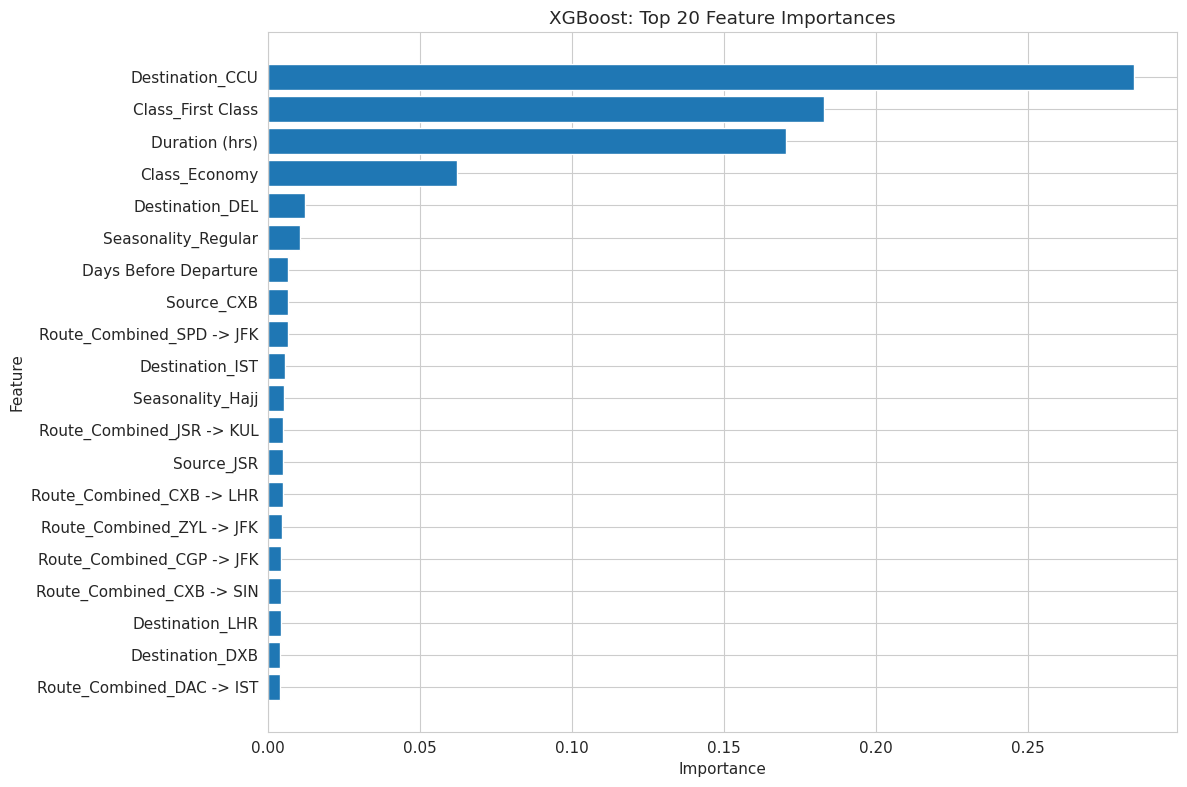

In [36]:
plot_actual_vs_predicted(y_test.values, xgb_pred, 'XGBoost')
plot_residuals(y_test.values, xgb_pred, 'XGBoost')
plot_feature_importance(xgb_model, feature_names, 'XGBoost')

### 6.5 Model Comparison Summary


MODEL COMPARISON (sorted by Test R2)
            Model  Train_R2  Test_R2   Train_RMSE    Test_RMSE    Train_MAE     Test_MAE  Test_MAPE  CV_R2_Mean  CV_R2_Std
    Random Forest  0.732644 0.677634 42295.144111 46357.309784 25787.714729 27848.398286  45.642024    0.679921   0.005968
          XGBoost  0.711971 0.677104 43899.900161 46395.437176 26764.535547 27945.260849  46.575207    0.680735   0.005601
Gradient Boosting  0.712128 0.677027 43887.959918 46400.964854 26772.152444 27926.917308  46.323745    0.680531   0.005465
    Decision Tree  0.717725 0.645536 43459.227454 48610.434976 26039.133985 28725.789356  46.397048    0.645384   0.007411
 Lasso Regression  0.575136 0.568639 53317.562313 53624.592130 40519.522112 40764.646202 251.885576    0.571092   0.004735
 Ridge Regression  0.575141 0.568571 53317.264012 53628.842169 40521.903083 40772.017843 251.969394    0.570979   0.004735
Linear Regression  0.575141 0.568567 53317.240574 53629.092849 40524.108755 40774.934403 252.032555  

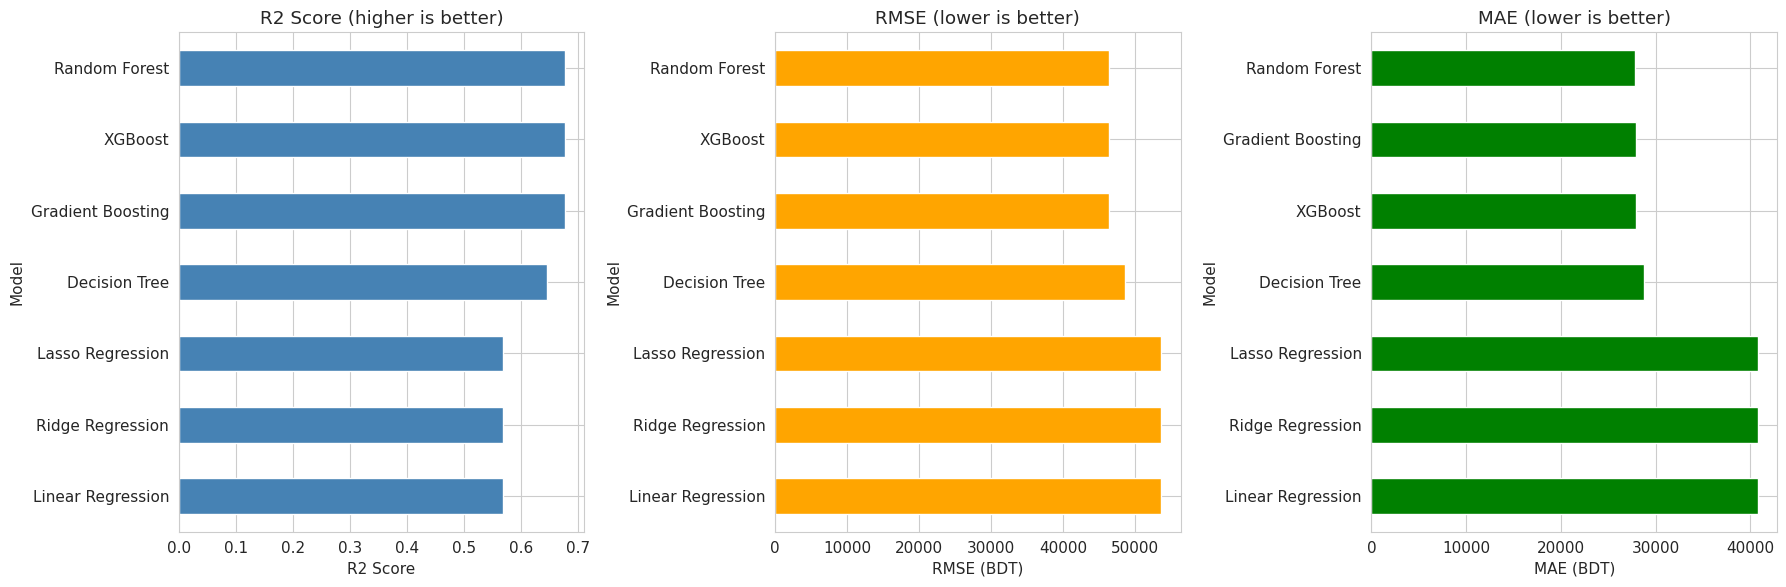

In [37]:
import pandas as pd

all_results = [lr_results, ridge_results, lasso_results, dt_results, rf_results, gb_results, xgb_results]
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Test_R2', ascending=False).reset_index(drop=True)

print('\n' + '='*80)
print('MODEL COMPARISON (sorted by Test R2)')
print('='*80)
print(results_df.to_string(index=False))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

r = results_df.sort_values('Test_R2', ascending=True)
r.plot.barh(x='Model', y='Test_R2', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('R2 Score (higher is better)')
axes[0].set_xlabel('R2 Score')

r = results_df.sort_values('Test_RMSE', ascending=False)
r.plot.barh(x='Model', y='Test_RMSE', ax=axes[1], legend=False, color='orange')
axes[1].set_title('RMSE (lower is better)')
axes[1].set_xlabel('RMSE (BDT)')

r = results_df.sort_values('Test_MAE', ascending=False)
r.plot.barh(x='Model', y='Test_MAE', ax=axes[2], legend=False, color='green')
axes[2].set_title('MAE (lower is better)')
axes[2].set_xlabel('MAE (BDT)')

plt.tight_layout()
plt.show()

### 6.6 Hyperparameter Tuning - Random Forest

In [38]:
# Optimized defaults: n_iter=20, cv=3 (~3-8 minutes)
# For faster tuning use: tune_random_forest_quick() (~1-4 minutes)
from src.optimization import tune_random_forest

print('\n' + '='*60)
print('TUNING RANDOM FOREST')
print('='*60)

rf_tuned, rf_params, rf_metrics, rf_pred_tuned = tune_random_forest(
    X_train, y_train, X_test, y_test
)

print(f'\nBest RF Parameters: {rf_params}')
print(f'Tuned RF - R2: {rf_metrics["R2"]:.6f}, RMSE: {rf_metrics["RMSE"]:.2f}, MAE: {rf_metrics["MAE"]:.2f}')


TUNING RANDOM FOREST
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best RF Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 5}
Tuned RF - R2: 0.678532, RMSE: 46292.68, MAE: 27944.42


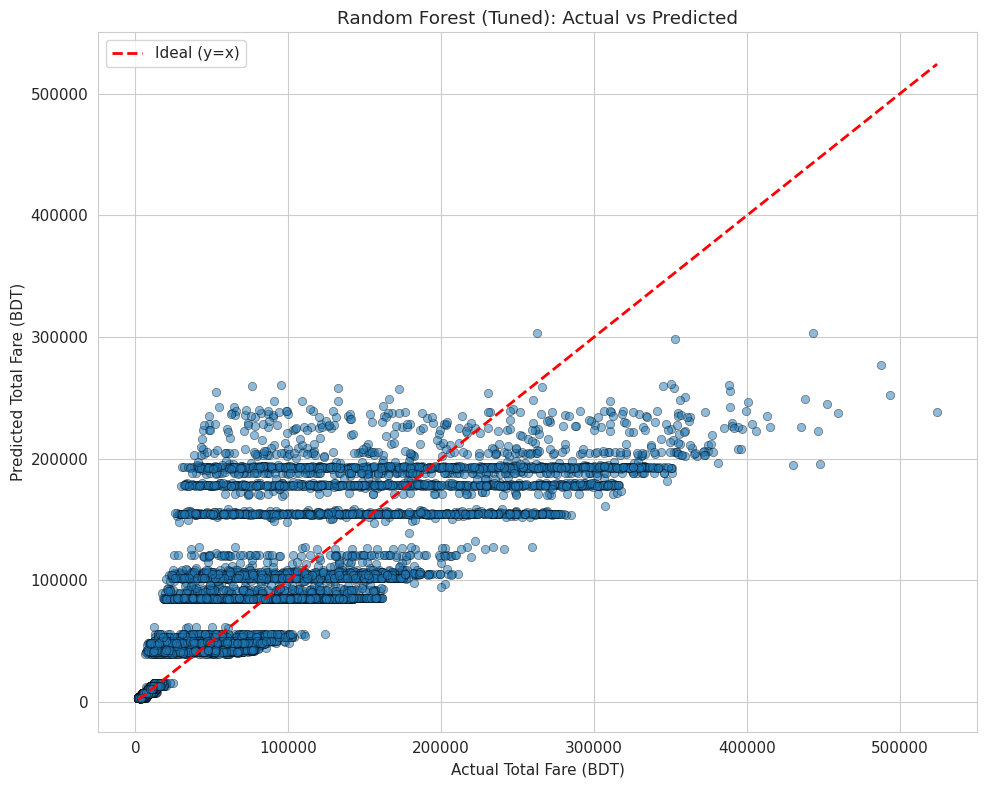

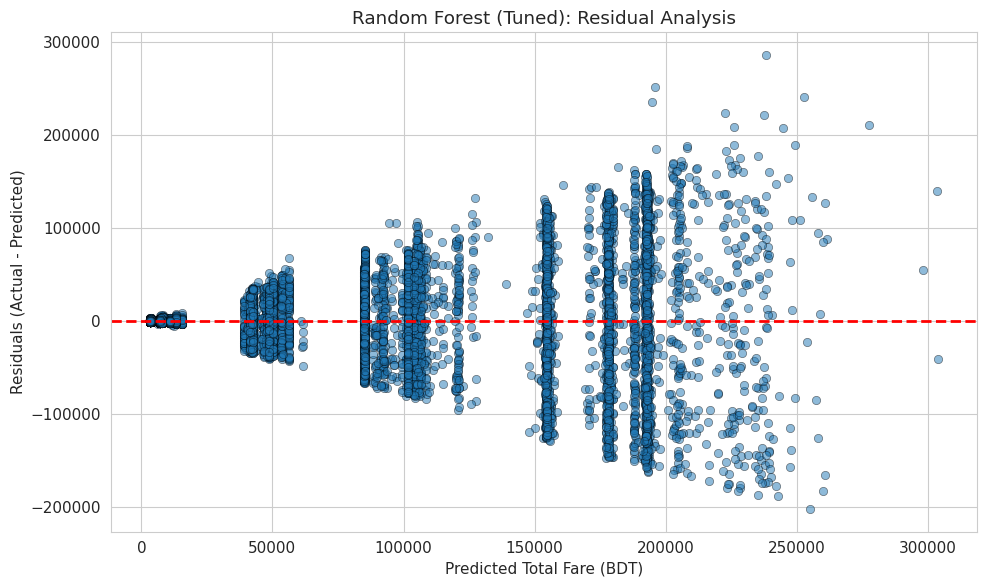

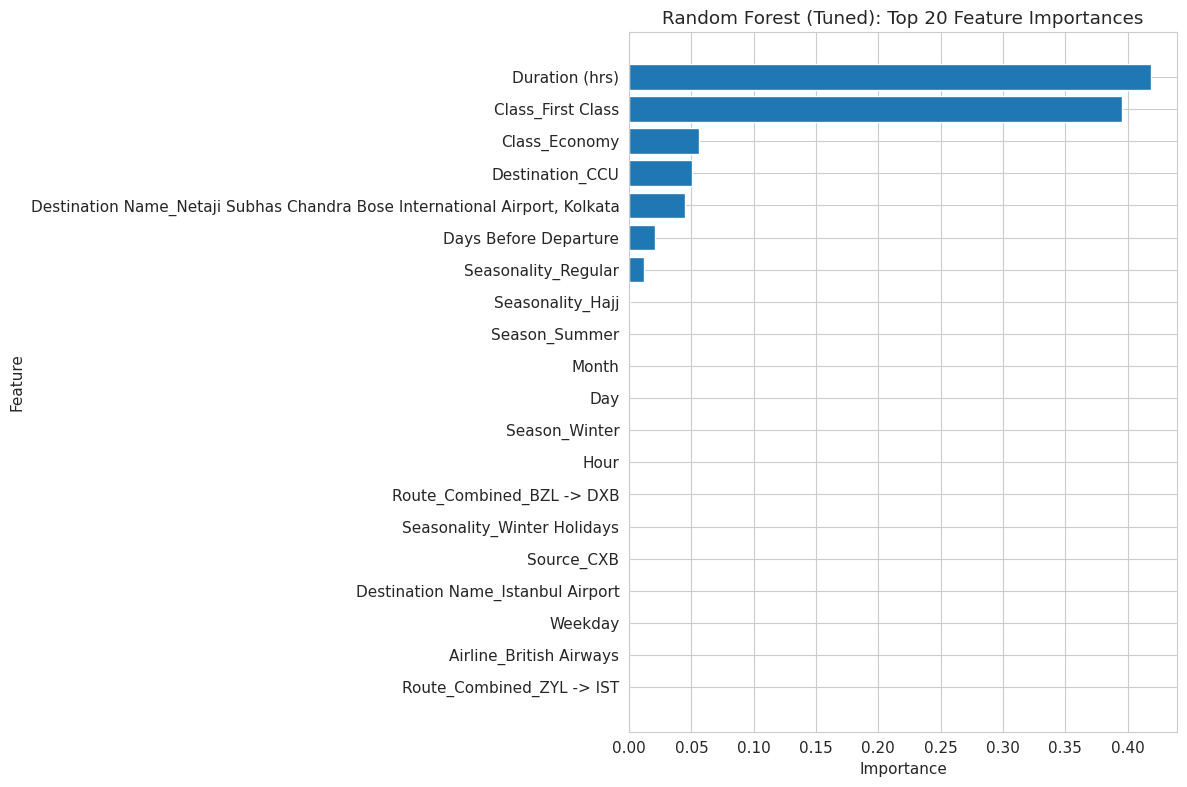

In [39]:
plot_actual_vs_predicted(y_test.values, rf_pred_tuned, 'Random Forest (Tuned)')
plot_residuals(y_test.values, rf_pred_tuned, 'Random Forest (Tuned)')
plot_feature_importance(rf_tuned, feature_names, 'Random Forest (Tuned)')

### 6.7 Hyperparameter Tuning - Gradient Boosting

In [40]:
# Optimized defaults: n_iter=20, cv=3 (~5-10 minutes)
# For faster tuning use: tune_gradient_boosting_quick() (~2-5 minutes)
from src.optimization import tune_gradient_boosting

print('\n' + '='*60)
print('TUNING GRADIENT BOOSTING')
print('='*60)

gb_tuned, gb_params, gb_metrics, gb_pred_tuned = tune_gradient_boosting(
    X_train, y_train, X_test, y_test
)

print(f'\nBest GB Parameters: {gb_params}')
print(f'Tuned GB - R2: {gb_metrics["R2"]:.6f}, RMSE: {gb_metrics["RMSE"]:.2f}, MAE: {gb_metrics["MAE"]:.2f}')


TUNING GRADIENT BOOSTING
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best GB Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 3, 'learning_rate': 0.05}
Tuned GB - R2: 0.678805, RMSE: 46273.07, MAE: 28115.74


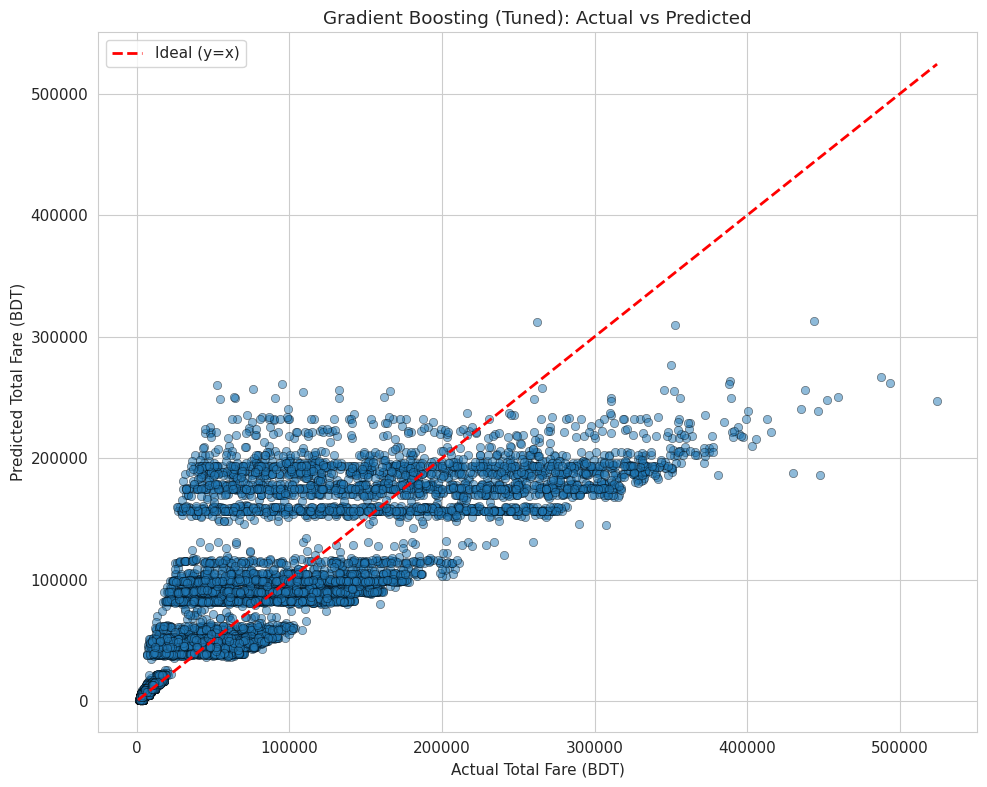

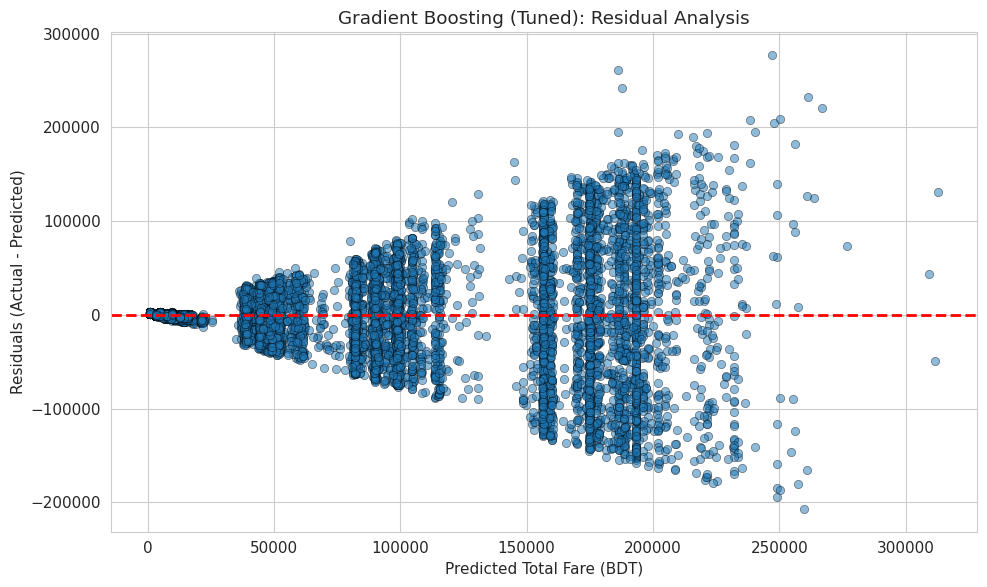

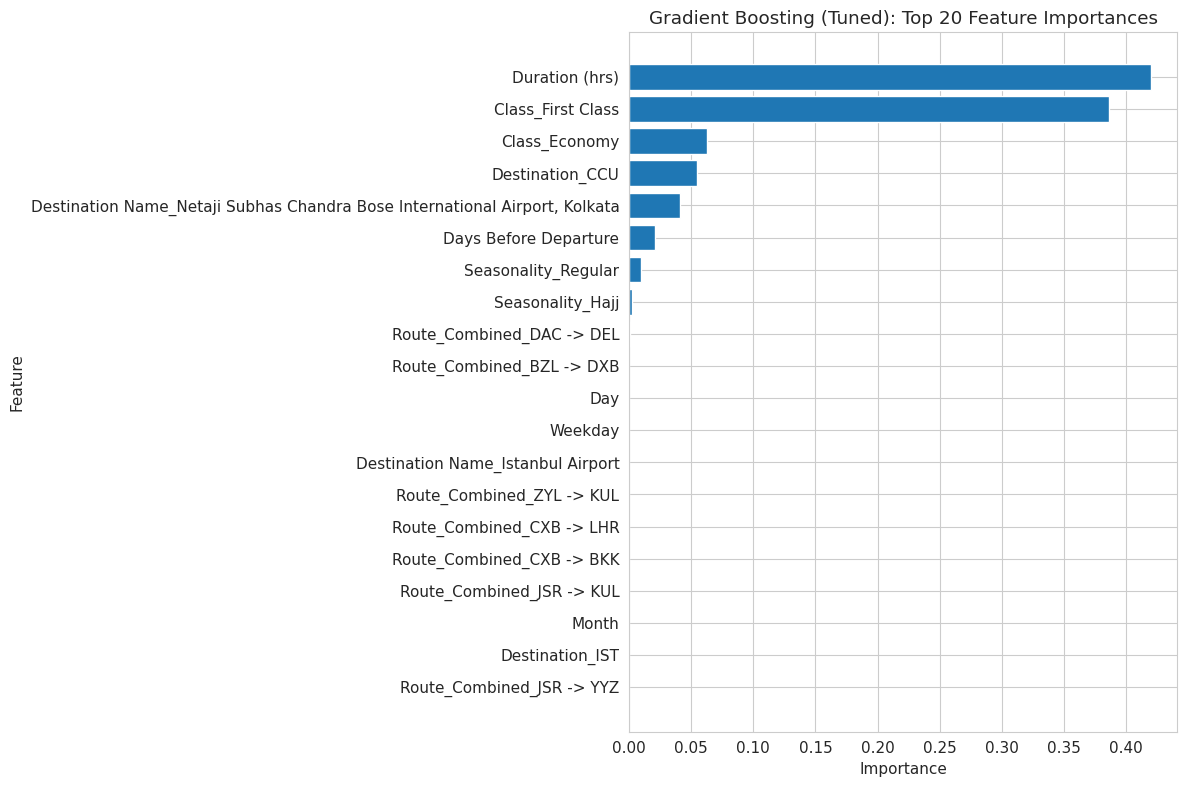

In [41]:
plot_actual_vs_predicted(y_test.values, gb_pred_tuned, 'Gradient Boosting (Tuned)')
plot_residuals(y_test.values, gb_pred_tuned, 'Gradient Boosting (Tuned)')
plot_feature_importance(gb_tuned, feature_names, 'Gradient Boosting (Tuned)')

### 6.8 Regularization Analysis


REGULARIZATION ANALYSIS


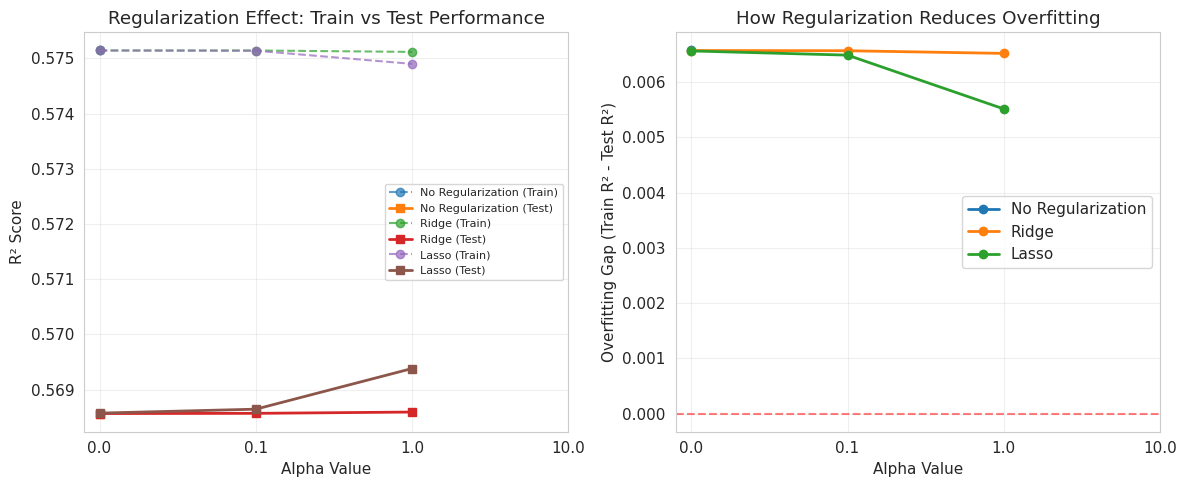

In [42]:
# Optimized defaults: 4 alphas, cv=3 (~2-5 minutes)
from src.optimization import compare_regularization, plot_regularization_effect

print('\n' + '='*60)
print('REGULARIZATION ANALYSIS')
print('='*60)

reg_results = compare_regularization(
    X_train, y_train, X_test, y_test,
)

plot_regularization_effect(reg_results)

### 6.9 Cross-Validation of Best Model

In [43]:
from src.optimization import cross_validate_best_model

if rf_metrics['R2'] >= gb_metrics['R2']:
    best_tuned_model = rf_tuned
    best_tuned_name = 'Random Forest (Tuned)'
    best_tuned_pred = rf_pred_tuned
    best_tuned_metrics = rf_metrics
else:
    best_tuned_model = gb_tuned
    best_tuned_name = 'Gradient Boosting (Tuned)'
    best_tuned_pred = gb_pred_tuned
    best_tuned_metrics = gb_metrics

print('\n' + '='*60)
print('CROSS-VALIDATION OF BEST MODEL')
print('='*60)
print(f'Best Tuned Model: {best_tuned_name}')
cv_results = cross_validate_best_model(best_tuned_model, X_train, y_train)
print(f'CV R2:  {cv_results["R2_mean"]:.6f} (+/- {cv_results["R2_std"]:.6f})')


CROSS-VALIDATION OF BEST MODEL
Best Tuned Model: Gradient Boosting (Tuned)
CV R2:  0.683208 (+/- 0.003763)


### 6.10 Final Model Comparison

In [44]:
import os

final_results = results_df.copy()

tuned_rf = pd.DataFrame([{
    'Model': 'Random Forest (Tuned)',
    'Train_R2': rf_metrics['R2'],
    'Test_R2': rf_metrics['R2'],
    'Train_RMSE': rf_metrics['RMSE'],
    'Test_RMSE': rf_metrics['RMSE'],
    'Train_MAE': rf_metrics['MAE'],
    'Test_MAE': rf_metrics['MAE'],
    'CV_R2_Mean': cv_results['R2_mean'],
    'CV_R2_Std': cv_results['R2_std']
}])

tuned_gb = pd.DataFrame([{
    'Model': 'Gradient Boosting (Tuned)',
    'Train_R2': gb_metrics['R2'],
    'Test_R2': gb_metrics['R2'],
    'Train_RMSE': gb_metrics['RMSE'],
    'Test_RMSE': gb_metrics['RMSE'],
    'Train_MAE': gb_metrics['MAE'],
    'Test_MAE': gb_metrics['MAE'],
    'CV_R2_Mean': cv_results['R2_mean'],
    'CV_R2_Std': cv_results['R2_std']
}])

final_results = pd.concat([final_results, tuned_rf, tuned_gb], ignore_index=True)
final_results = final_results.sort_values('Test_R2', ascending=False).reset_index(drop=True)

os.makedirs('reports', exist_ok=True)
final_results.to_csv('reports/model_comparison.csv', index=False)

print('\n' + '='*80)
print('FINAL MODEL COMPARISON (saved to reports/model_comparison.csv)')
print('='*80)
print(final_results.to_string(index=False))


FINAL MODEL COMPARISON (saved to reports/model_comparison.csv)
                    Model  Train_R2  Test_R2   Train_RMSE    Test_RMSE    Train_MAE     Test_MAE  Test_MAPE  CV_R2_Mean  CV_R2_Std
Gradient Boosting (Tuned)  0.678805 0.678805 46273.068912 46273.068912 28115.736151 28115.736151        NaN    0.683208   0.003763
    Random Forest (Tuned)  0.678532 0.678532 46292.684903 46292.684903 27944.419217 27944.419217        NaN    0.683208   0.003763
            Random Forest  0.732644 0.677634 42295.144111 46357.309784 25787.714729 27848.398286  45.642024    0.679921   0.005968
                  XGBoost  0.711971 0.677104 43899.900161 46395.437176 26764.535547 27945.260849  46.575207    0.680735   0.005601
        Gradient Boosting  0.712128 0.677027 43887.959918 46400.964854 26772.152444 27926.917308  46.323745    0.680531   0.005465
            Decision Tree  0.717725 0.645536 43459.227454 48610.434976 26039.133985 28725.789356  46.397048    0.645384   0.007411
         Lasso Regr

In [54]:
# Save Best Model and Scaler for Deployment
import pickle

# Create models directory
os.makedirs('./models', exist_ok=True)

# Save the best tuned model
best_model_path = './models/best_model.pkl'
with open(best_model_path, 'wb') as f:
    pickle.dump(best_tuned_model, f)
print(f'Best model saved to: {best_model_path}')

# Save the scaler
scaler_path = './models/scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f'Scaler saved to: {scaler_path}')

# Save feature names for reference
feature_names_path = './models/feature_names.txt'
with open(feature_names_path, 'w') as f:
    f.write('\n'.join(feature_names))
print(f'Feature names saved to: {feature_names_path}')

print('\n' + '='*80)
print('MODEL ARTIFACTS SAVED SUCCESSFULLY')
print('='*80)
print(f'  - Model type: {type(best_tuned_model).__name__}')
print(f'  - Model size: {os.path.getsize(best_model_path) / 1024:.2f} KB')
print(f'  - Scaler type: {type(scaler).__name__}')
print(f'  - Number of features: {len(feature_names)}')

Best model saved to: ./models/best_model.pkl
Scaler saved to: ./models/scaler.pkl
Feature names saved to: ./models/feature_names.txt

MODEL ARTIFACTS SAVED SUCCESSFULLY
  - Model type: GradientBoostingRegressor
  - Model size: 214.35 KB
  - Scaler type: RobustScaler
  - Number of features: 248


## Step 7: Model Interpretation & Insights

### 7.1 Feature Importance Analysis

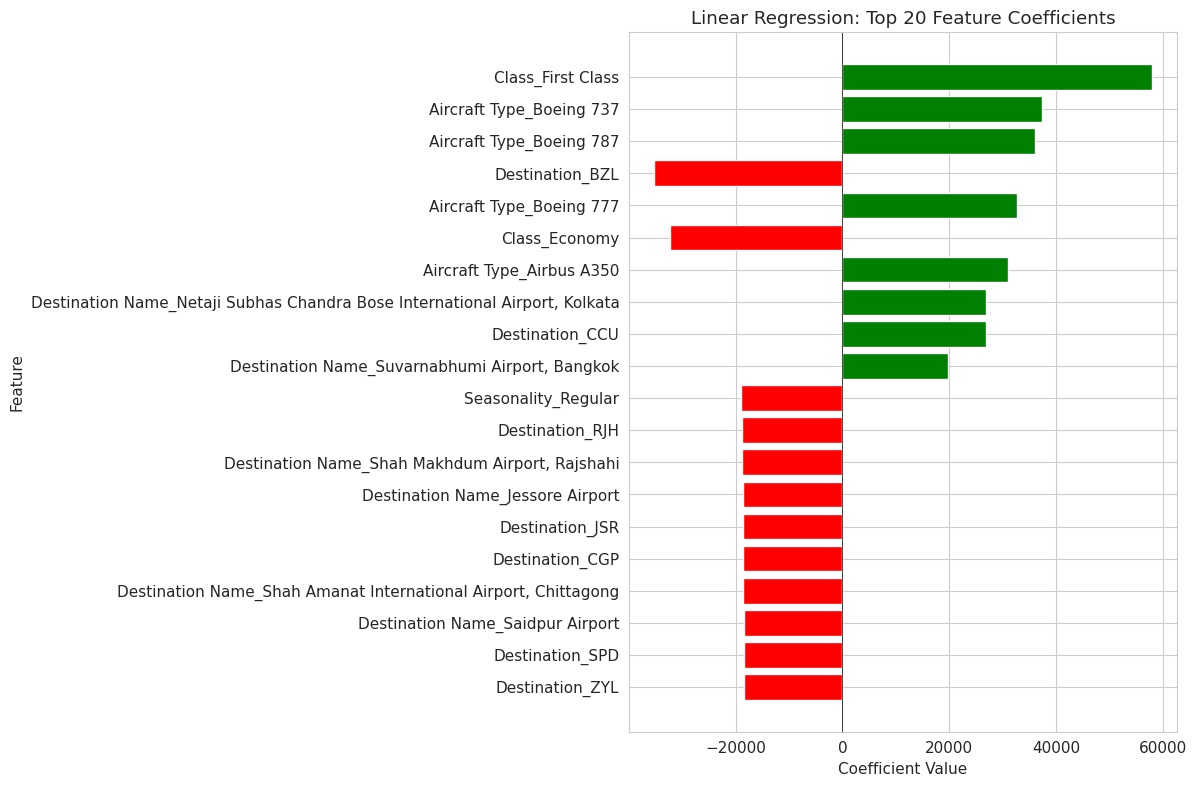

In [46]:
from src.interpretation import plot_linear_coefficients, plot_tree_feature_importance

plot_linear_coefficients(lr_model, feature_names, 'Linear Regression')

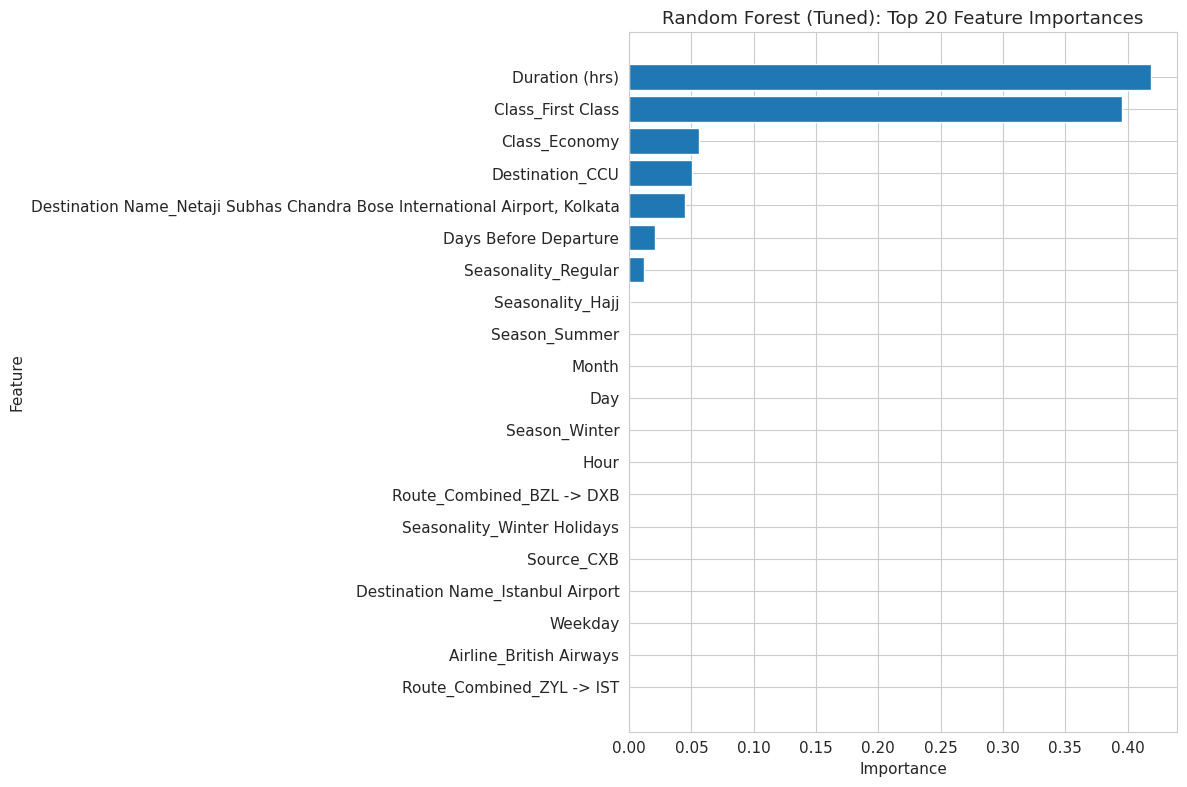

In [47]:
plot_tree_feature_importance(rf_tuned, feature_names, 'Random Forest (Tuned)')

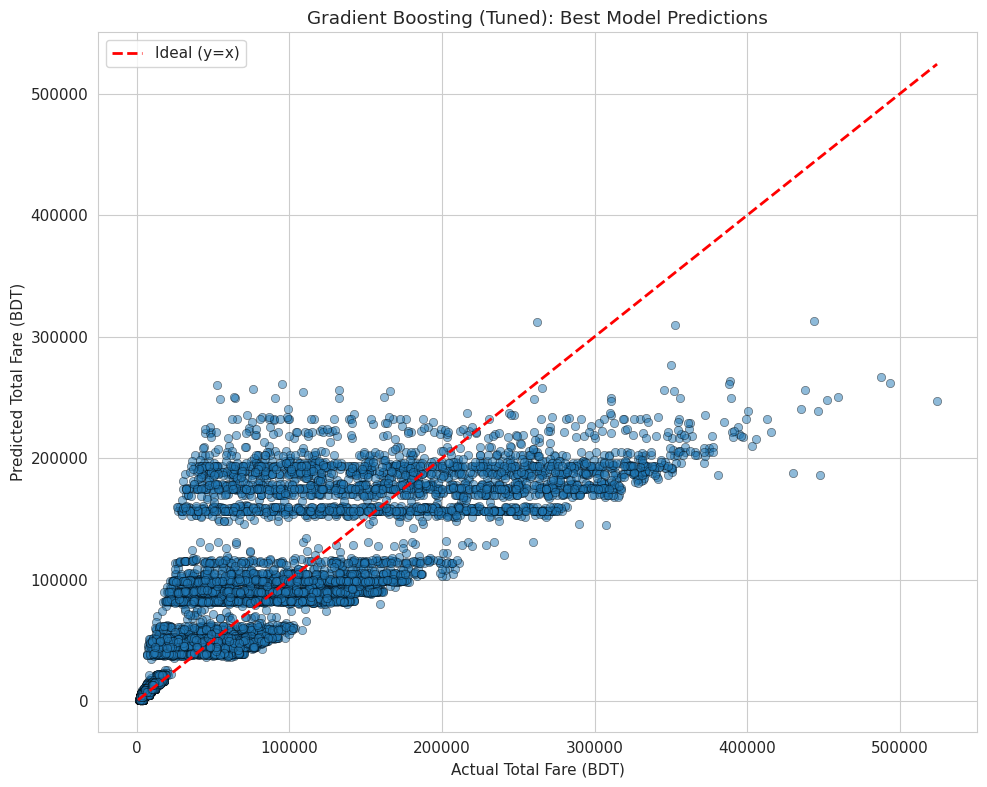

In [48]:
from src.interpretation import plot_best_model_predictions

plot_best_model_predictions(y_test.values, best_tuned_pred, best_tuned_name)

### 7.2 Key Insights & Recommendations

In [49]:
from src.interpretation import generate_insights, summarize_findings
from src.eda import summarize_fares

fare_summary = summarize_fares(df_clean)
insights = generate_insights(df_clean, best_tuned_model, feature_names, final_results, fare_summary)
print(summarize_findings(insights))

FLIGHT FARE PREDICTION - ANALYSIS SUMMARY

1. KEY FACTORS AFFECTING FLIGHT FARES:
   1. {'Feature': 'Duration (hrs)', 'Importance': 0.42010657882848795}
   2. {'Feature': 'Class_First Class', 'Importance': 0.38637661552863395}
   3. {'Feature': 'Class_Economy', 'Importance': 0.06295623854811089}
   4. {'Feature': 'Destination_CCU', 'Importance': 0.054473527252356185}
   5. {'Feature': 'Destination Name_Netaji Subhas Chandra Bose International Airport, Kolkata', 'Importance': 0.04103462666293321}

2. AIRLINE PRICING PATTERNS:
   Most Expensive: Turkish Airlines, AirAsia, Cathay Pacific
   Cheapest: NovoAir, Singapore Airlines, Vistara

3. SEASONAL PRICE VARIATION:
   Hajj: 97,144.47 BDT
   Eid: 91,560.02 BDT
   Winter Holidays: 79,676.74 BDT
   Regular: 68,077.27 BDT

4. MODEL RECOMMENDATION:
   Best Model: Gradient Boosting (Tuned)
   Test R2: 0.6788
   Test RMSE: 46273.07 BDT

END OF REPORT


In [55]:
import shutil

# Create zip file from kaggle working directory
shutil.make_archive(
    base_name="/kaggle/working/kaggle_working_result",  # output file name (without .zip)
    format="zip",
    root_dir="/kaggle/working"
)

print("Zip file created successfully!")


Zip file created successfully!


In [56]:
from IPython.display import FileLink

FileLink('/kaggle/working/kaggle_working_result.zip')


/kaggle/working/kaggle_working_result.zip